In [52]:
import pandas as pd


In [53]:
pd.read_csv('/content/customer_shopping_behavior.csv')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [54]:
df = pd.read_csv('/content/customer_shopping_behavior.csv')
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [55]:
mean_review_rating = df['Review Rating'].mean()
df['Review Rating'].fillna(mean_review_rating, inplace=True)
print(f"Missing values in 'Review Rating' filled with mean: {mean_review_rating:.2f}")
df.isnull().sum()

Missing values in 'Review Rating' filled with mean: 3.75


/tmp/ipykernel_856/2501546012.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review Rating'].fillna(mean_review_rating, inplace=True)


,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


### 1. Confirm Missing Values
First, let's confirm that all missing values have been handled. Based on the previous steps, the 'Review Rating' column should now be filled.

In [56]:
print('Missing values after filling Review Rating:')
display(df.isnull().sum())

Missing values after filling Review Rating:


,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


### 2. Remove Duplicate Rows
Next, I'll check for and remove any duplicate rows in the dataset.

In [57]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
removed_rows = initial_rows - df.shape[0]
print(f"Number of duplicate rows removed: {removed_rows}")
print(f"DataFrame shape after removing duplicates: {df.shape}")

Number of duplicate rows removed: 0
DataFrame shape after removing duplicates: (3900, 18)


### 3. Clean Column Names
I will clean column names by converting them to lowercase and replacing spaces with underscores for easier access.

In [58]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('_(usd)', '', regex=False)
print("Cleaned column names:")
display(df.columns.tolist())

Cleaned column names:


['customer_id',
 'age',
 'gender',
 'item_purchased',
 'category',
 'purchase_amount',
 'location',
 'size',
 'color',
 'season',
 'review_rating',
 'subscription_status',
 'shipping_type',
 'discount_applied',
 'promo_code_used',
 'previous_purchases',
 'payment_method',
 'frequency_of_purchases']

### 4. Correct Data Types and Standardize Yes/No Fields
I'll inspect the current data types and make necessary corrections. Also, I'll standardize 'Yes/No' fields to boolean (True/False) or numerical (1/0) for consistency, depending on how they are used.

In [59]:
print("Current data types:")
display(df.info())

# Standardize 'Yes/No' columns
# Identify columns that contain 'Yes' or 'No'
yes_no_columns = ['subscription_status', 'discount_applied', 'promo_code_used']

for col in yes_no_columns:
    if col in df.columns:
        df[col] = df[col].map({'Yes': True, 'No': False}).astype(bool)
        print(f"Column '{col}' standardized to boolean.")

print("Data types after standardization:")
display(df.info())

Current data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount         3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used     

None

Column 'subscription_status' standardized to boolean.
Column 'discount_applied' standardized to boolean.
Column 'promo_code_used' standardized to boolean.
Data types after standardization:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount         3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscripti

None

### 5. Check for Spelling Inconsistency in Categories
To check for spelling inconsistencies, I will display the unique values for key categorical columns. Please review these and let me know if any values need to be standardized or corrected.

In [60]:
categorical_cols = ['gender', 'category', 'location', 'size', 'color', 'season', 'shipping_type', 'payment_method', 'frequency_of_purchases']

for col in categorical_cols:
    if col in df.columns:
        print(f"\nUnique values for '{col}':")
        display(df[col].value_counts())


Unique values for 'gender':


,count
gender,
Male,2652
Female,1248



Unique values for 'category':


,count
category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324



Unique values for 'location':


...

,count
shipping_type,
Free Shipping,675
Standard,654
Store Pickup,650
Next Day Air,648
Express,646
2-Day Shipping,627



Unique values for 'payment_method':


,count
payment_method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612



Unique values for 'frequency_of_purchases':


,count
frequency_of_purchases,
Every 3 Months,584
Annually,572
Quarterly,563
Monthly,553
Bi-Weekly,547
Fortnightly,542
Weekly,539


## 4. Univariate Analysis - Numerical Columns

Let's analyze the distribution of numerical variables, calculate key statistics, and visualize them using histograms and boxplots.

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['age', 'purchase_amount', 'review_rating', 'previous_purchases']

print("### Descriptive Statistics for Numerical Columns ###")
display(df[numerical_cols].describe())


### Descriptive Statistics for Numerical Columns ###


,age,purchase_amount,review_rating,previous_purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.750065,25.351538
std,15.207589,23.685392,0.713573,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.750065,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


### Analysis of 'Age'

- **Average age kya hai?**

Average Age: 44.07


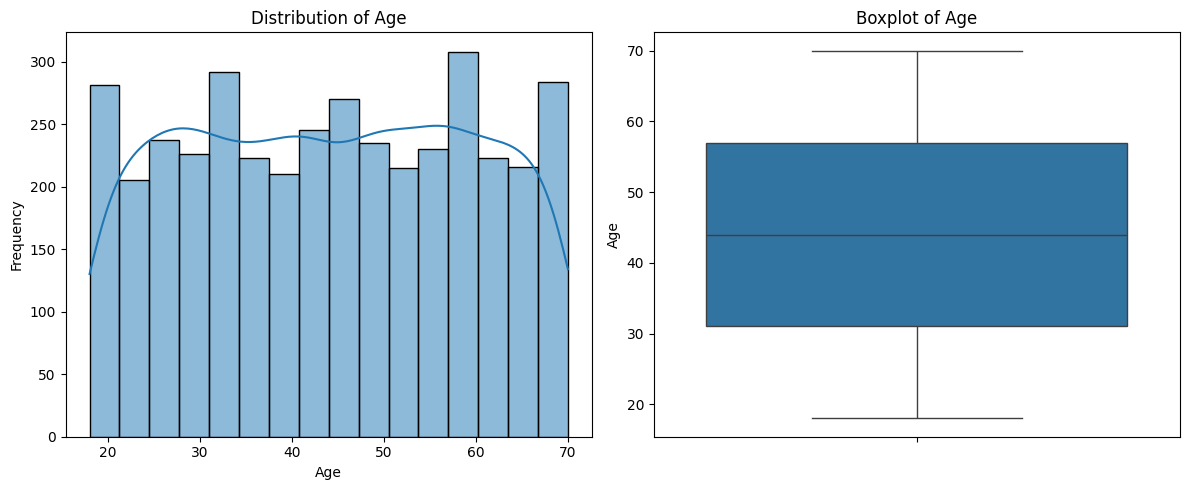

In [62]:
print(f"Average Age: {df['age'].mean():.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

### Analysis of 'Purchase Amount'

- **Average purchase amount?**
- **Minimum/maximum purchase?**

Average Purchase Amount: $59.76
Minimum Purchase Amount: $20.00
Maximum Purchase Amount: $100.00


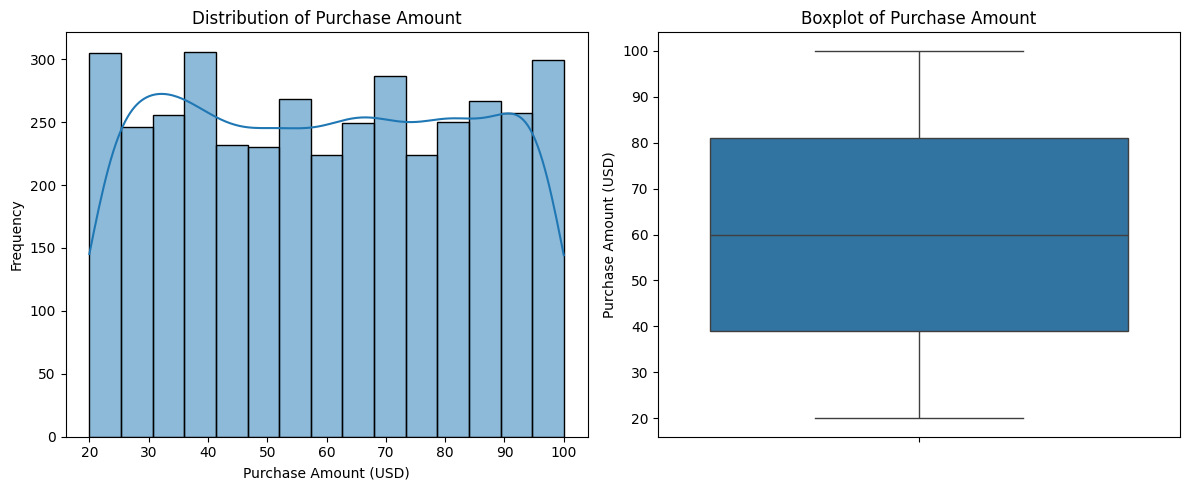

In [63]:
print(f"Average Purchase Amount: ${df['purchase_amount'].mean():.2f}")
print(f"Minimum Purchase Amount: ${df['purchase_amount'].min():.2f}")
print(f"Maximum Purchase Amount: ${df['purchase_amount'].max():.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['purchase_amount'], kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['purchase_amount'])
plt.title('Boxplot of Purchase Amount')
plt.ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.show()

### Analysis of 'Review Rating'

- **Rating distribution?**

Review Rating Distribution:


,count
review_rating,
2.500000,66
2.600000,158
2.700000,154
2.800000,136
2.900000,166
3.000000,162
3.100000,156
3.200000,152
3.300000,146


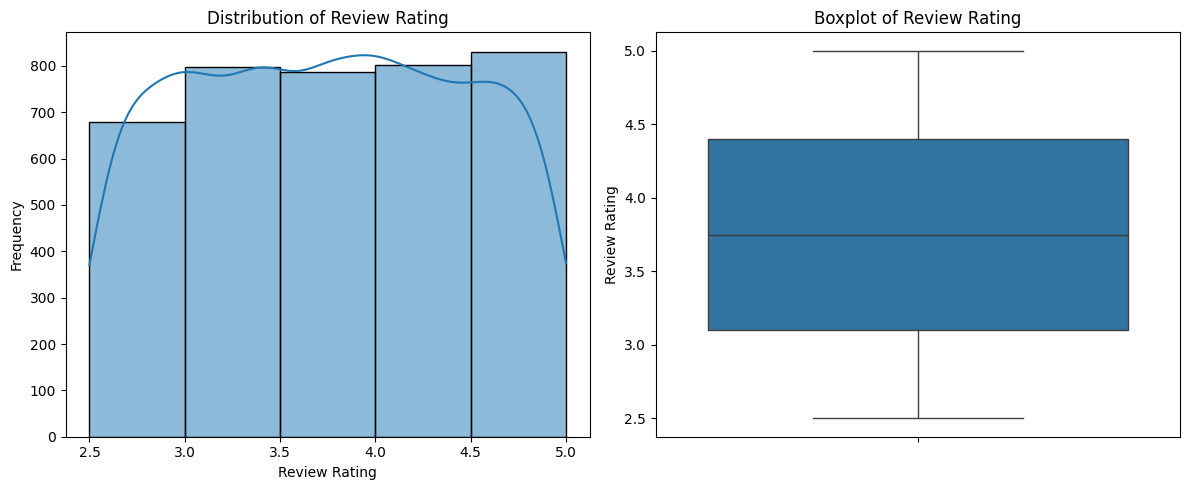

In [64]:
print("Review Rating Distribution:")
display(df['review_rating'].value_counts().sort_index())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['review_rating'], bins=5, kde=True)
plt.title('Distribution of Review Rating')
plt.xlabel('Review Rating')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['review_rating'])
plt.title('Boxplot of Review Rating')
plt.ylabel('Review Rating')

plt.tight_layout()
plt.show()

### Analysis of 'Previous Purchases'

- **Customers ke previous purchases kitne hain? (Average)**

Average Previous Purchases: 25.35


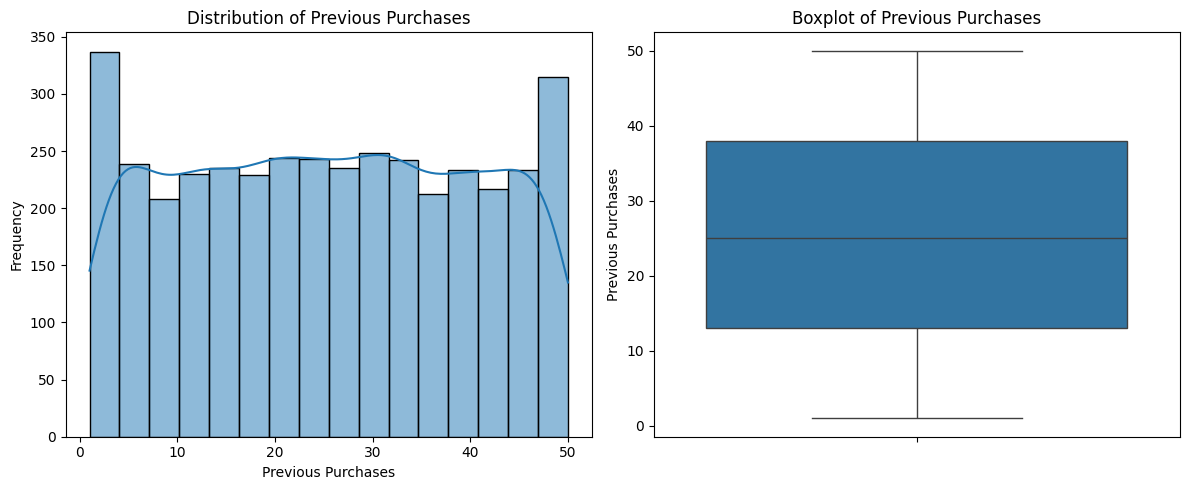

In [65]:
print(f"Average Previous Purchases: {df['previous_purchases'].mean():.2f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['previous_purchases'], kde=True)
plt.title('Distribution of Previous Purchases')
plt.xlabel('Previous Purchases')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['previous_purchases'])
plt.title('Boxplot of Previous Purchases')
plt.ylabel('Previous Purchases')

plt.tight_layout()
plt.show()

In [66]:
df["gender"].value_counts()

,count
gender,
Male,2652
Female,1248



### Univariate Analysis - Categorical Columns ###

--- Analysis of 'Gender' ---
Value Counts:


,count
gender,
Male,2652
Female,1248


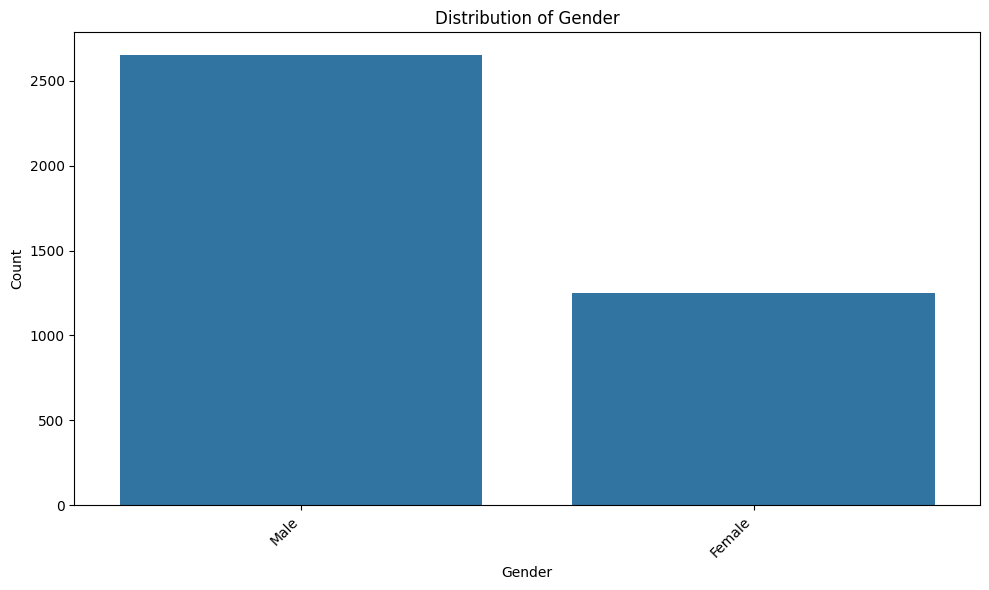


--- Analysis of 'Category' ---
Value Counts:


,count
category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324


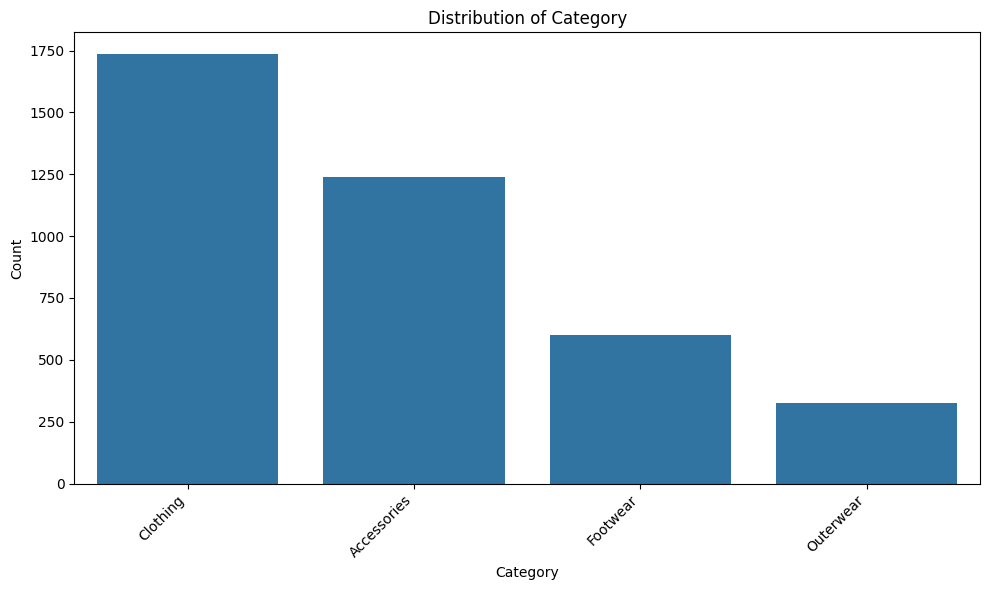


--- Analysis of 'Location' ---
Value Counts:


,count
location,
Montana,96
California,95
Idaho,93
Illinois,92
Alabama,89
Minnesota,88
New York,87
Nevada,87
Nebraska,87


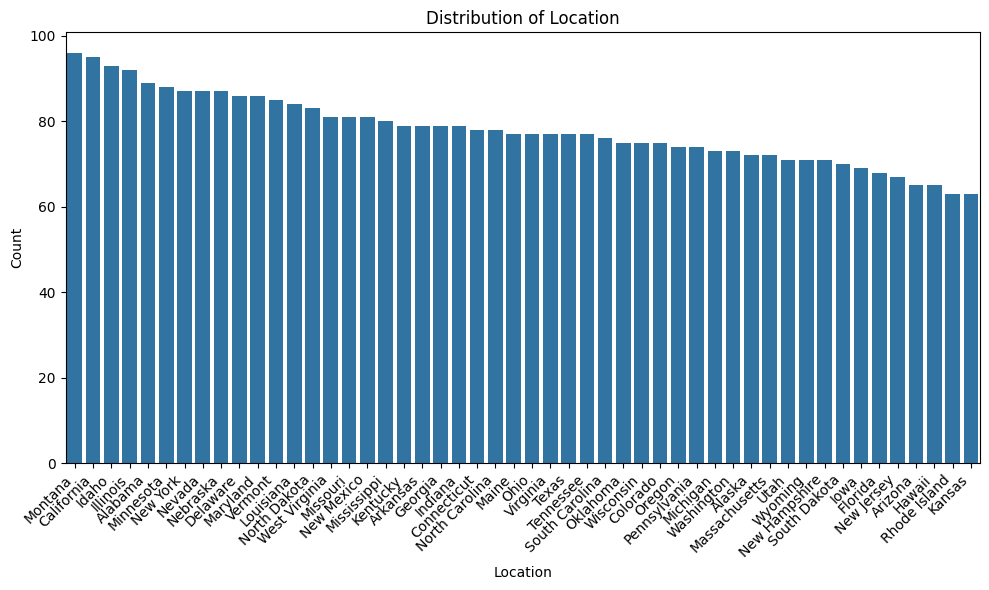


--- Analysis of 'Season' ---
Value Counts:


,count
season,
Spring,999
Fall,975
Winter,971
Summer,955


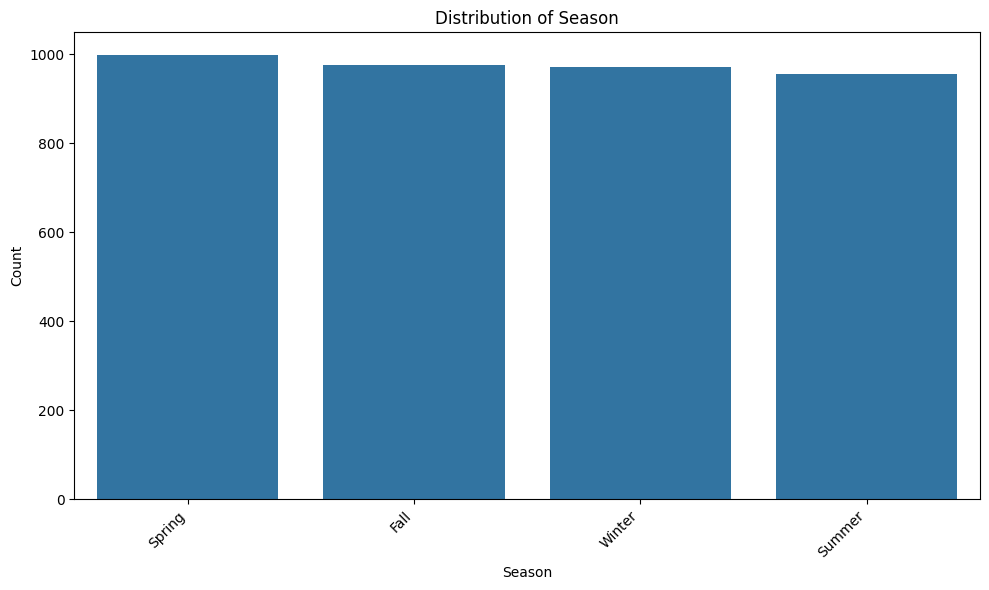


--- Analysis of 'Size' ---
Value Counts:


,count
size,
M,1755
L,1053
S,663
XL,429


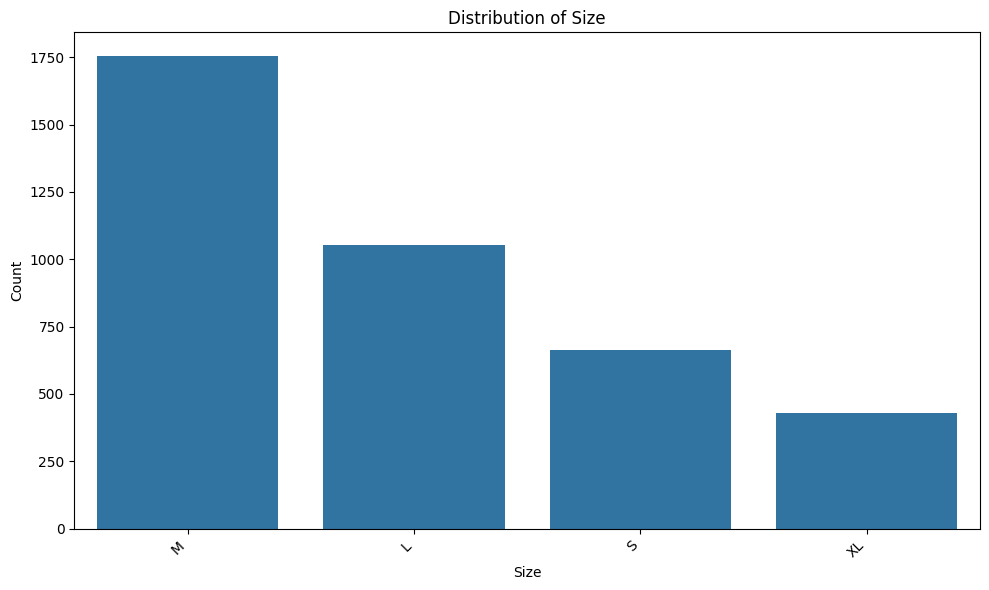


--- Analysis of 'Color' ---
Value Counts:


,count
color,
Olive,177
Yellow,174
Silver,173
Teal,172
Green,169
Black,167
Cyan,166
Violet,166
Gray,159


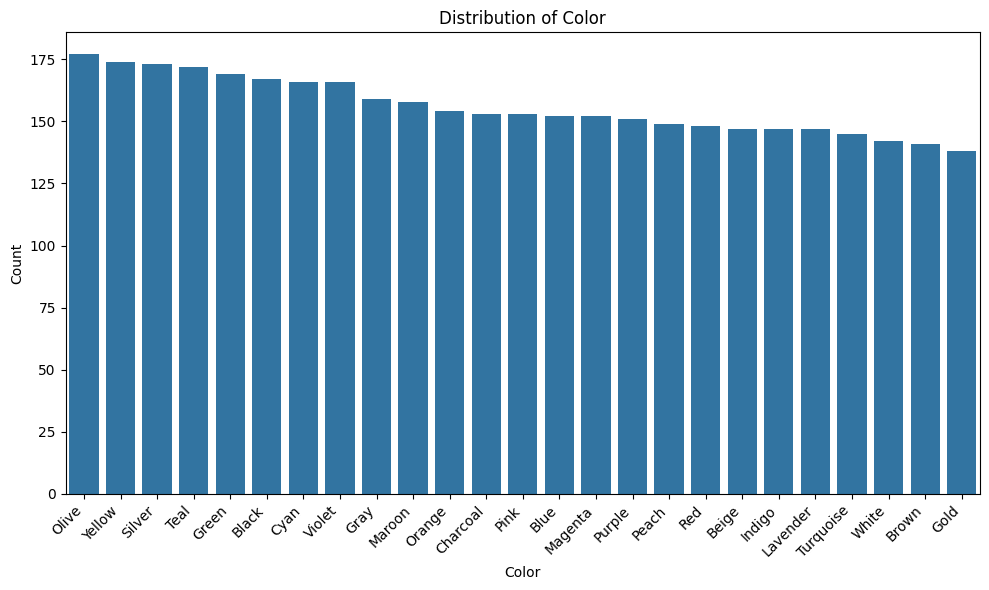


--- Analysis of 'Payment Method' ---
Value Counts:


,count
payment_method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612


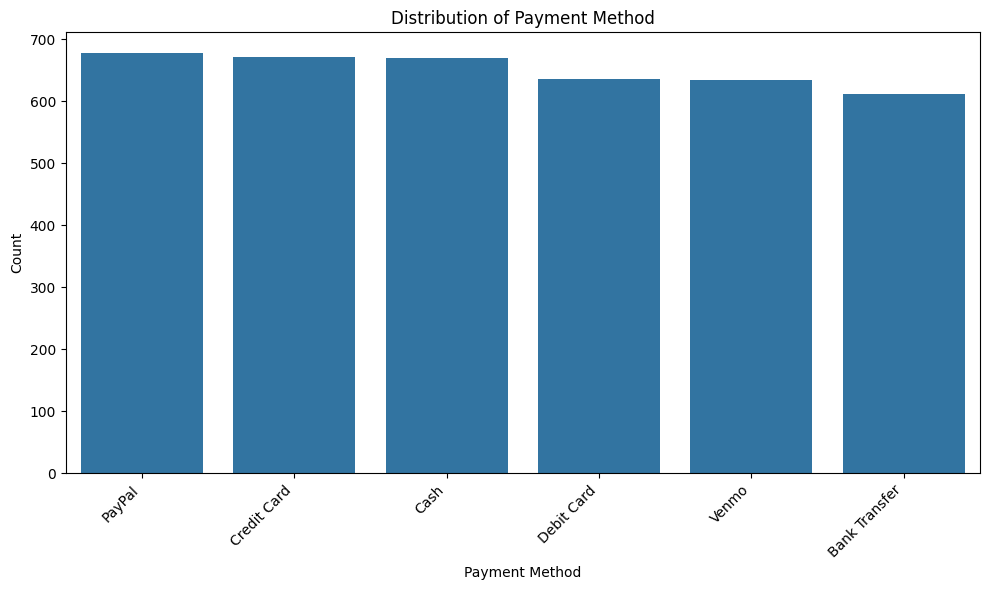


--- Analysis of 'Shipping Type' ---
Value Counts:


,count
shipping_type,
Free Shipping,675
Standard,654
Store Pickup,650
Next Day Air,648
Express,646
2-Day Shipping,627


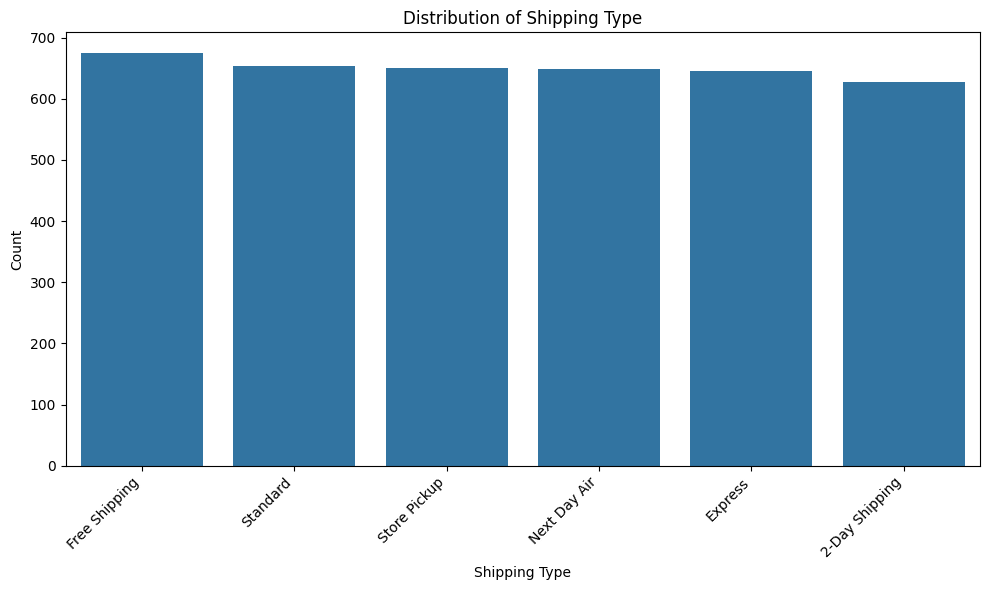


--- Analysis of 'Frequency Of Purchases' ---
Value Counts:


,count
frequency_of_purchases,
Every 3 Months,584
Annually,572
Quarterly,563
Monthly,553
Bi-Weekly,547
Fortnightly,542
Weekly,539


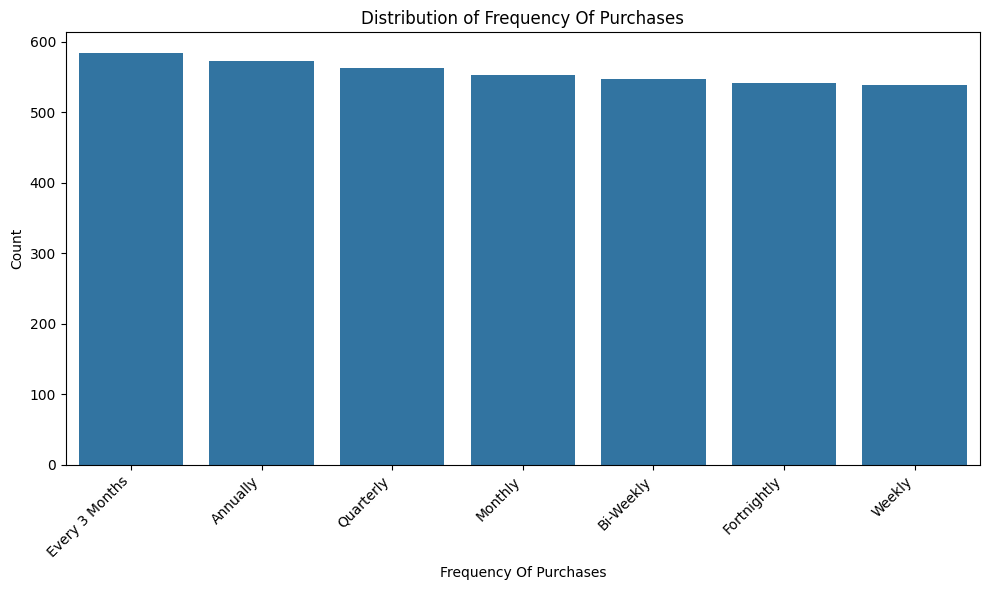


--- Analysis of 'Subscription Status' ---
Value Counts:


,count
subscription_status,
False,2847
True,1053


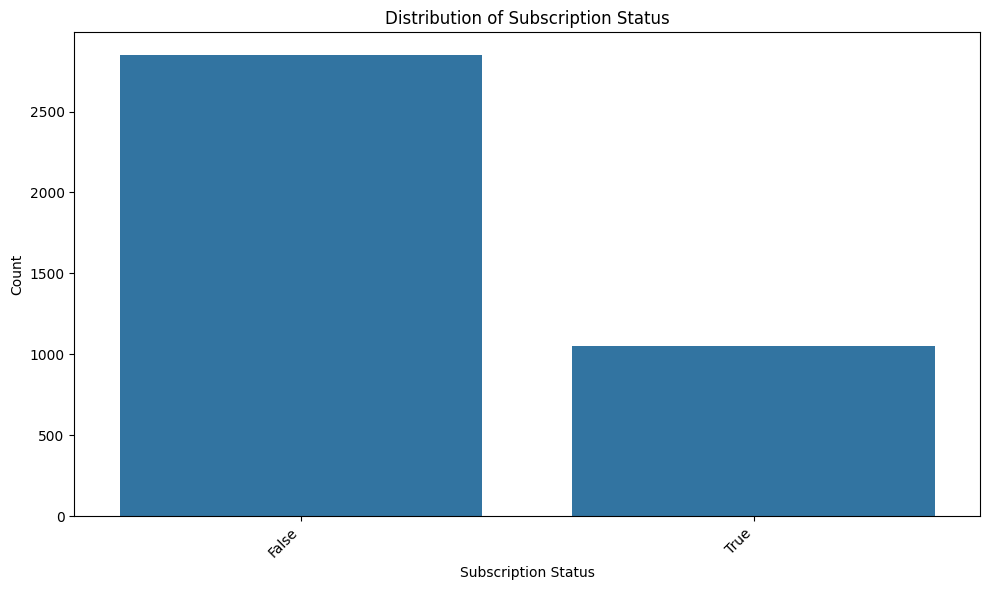

In [67]:
print("\n### Univariate Analysis - Categorical Columns ###")
categorical_cols_to_analyze = [
    'gender',
    'category',
    'location',
    'season',
    'size',
    'color',
    'payment_method',
    'shipping_type',
    'frequency_of_purchases',
    'subscription_status'
]

for col in categorical_cols_to_analyze:
    if col in df.columns:
        print(f"\n--- Analysis of '{col.replace('_', ' ').title()}' ---")
        print("Value Counts:")
        display(df[col].value_counts())

        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col.replace("_", " ").title()}')
        plt.xlabel(col.replace('_', ' ').title())
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in the DataFrame.")

In [68]:
# 4. Geographic and Frequency Spend Analysis
print("### Top 10 Locations by Mean Purchase Amount ###")
state_avg_spend = df.groupby('location')['purchase_amount'].agg(['count', 'mean', 'sum']).sort_values(by='mean', ascending=False).head(10)
display(state_avg_spend)

print("\n### Frequency of Purchases x Purchase Amount ###")
freq_spend = df.groupby('frequency_of_purchases')['purchase_amount'].agg(['count', 'mean', 'sum']).sort_values(by='mean', ascending=False)
display(freq_spend)

### Top 10 Locations by Mean Purchase Amount ###


,count,mean,sum
location,,,
Alaska,72,67.597222,4867
Pennsylvania,74,66.567568,4926
Arizona,65,66.553846,4326
West Virginia,81,63.876543,5174
Nevada,87,63.379310,5514
Washington,73,63.328767,4623
North Dakota,83,62.891566,5220
Virginia,77,62.883117,4842
Utah,71,62.577465,4443



### Frequency of Purchases x Purchase Amount ###


,count,mean,sum
frequency_of_purchases,,,
Bi-Weekly,547,60.694698,33200
Annually,572,60.173077,34419
Every 3 Months,584,60.082192,35088
Quarterly,563,59.984014,33771
Monthly,553,59.330922,32810
Fortnightly,542,59.053506,32007
Weekly,539,58.972171,31786


### Gender Distribution ###


,count
gender,
Male,2652
Female,1248


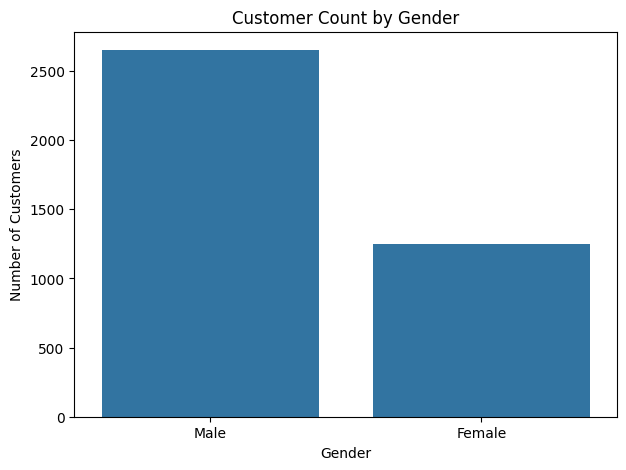


### Average Purchase Amount by Gender ###


,purchase_amount
gender,
Female,60.249199
Male,59.536199


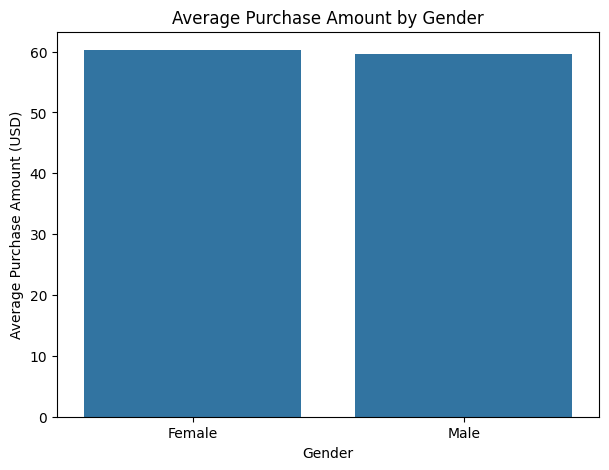


### Customers by Age Group ###


,count
age_group,
18-25,486
26-35,755
36-45,729
46-55,752
56+,1178


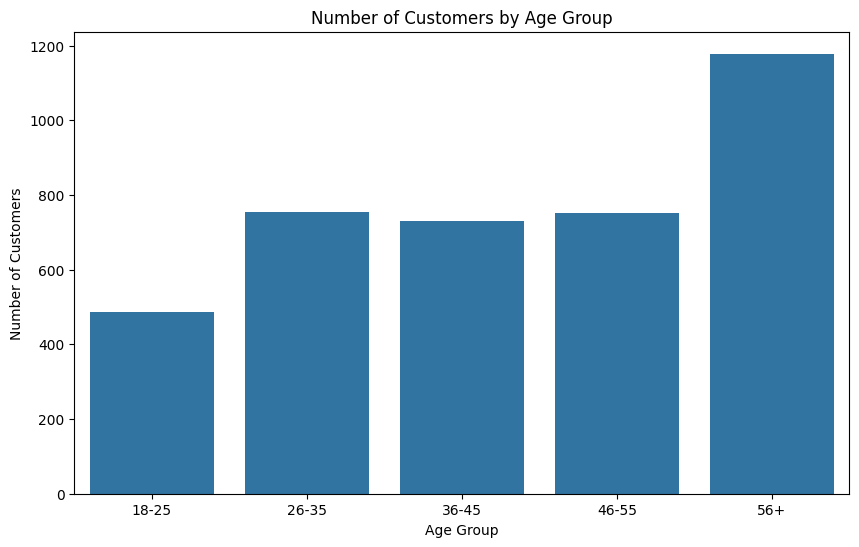


### Revenue by Age Group ###


/tmp/ipykernel_856/123367110.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum().sort_index()


,purchase_amount
age_group,
18-25,29258
26-35,45400
36-45,43463
46-55,45370
56+,69590


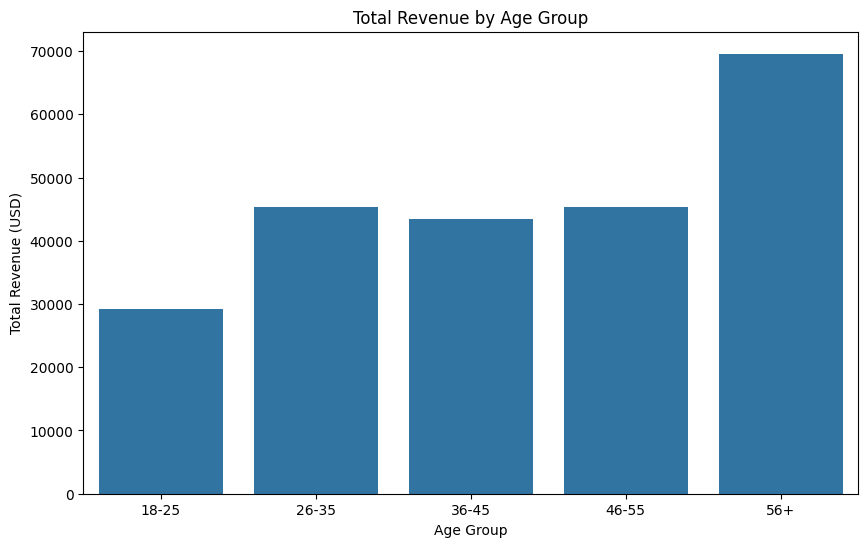


### Average Purchase by Age Group ###


/tmp/ipykernel_856/123367110.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_purchase_by_age_group = df.groupby('age_group')['purchase_amount'].mean().sort_index()


,purchase_amount
age_group,
18-25,60.201646
26-35,60.132450
36-45,59.620027
46-55,60.332447
56+,59.074703


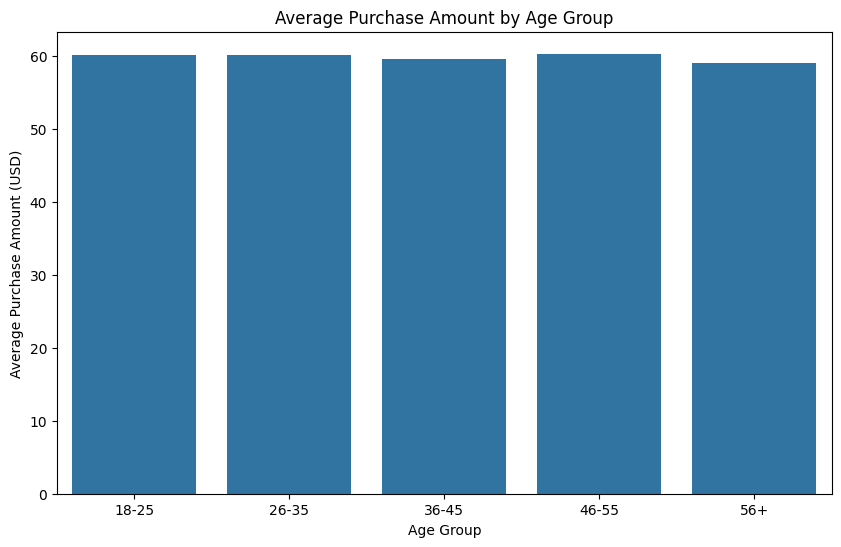

In [69]:
## 5. Customer Demographic Analysis

### Gender Analysis

print("### Gender Distribution ###")
gender_counts = df['gender'].value_counts()
display(gender_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.title('Customer Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

print("\n### Average Purchase Amount by Gender ###")
average_purchase_by_gender = df.groupby('gender')['purchase_amount'].mean().sort_values(ascending=False)
display(average_purchase_by_gender)

plt.figure(figsize=(7, 5))
sns.barplot(x=average_purchase_by_gender.index, y=average_purchase_by_gender.values)
plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

### Age Group Analysis

# Create age groups
AGE_BINS = [18, 25, 35, 45, 55, df['age'].max() + 1] # +1 to include the max age
AGE_LABELS = ['18-25', '26-35', '36-45', '46-55', '56+']
df['age_group'] = pd.cut(df['age'], bins=AGE_BINS, labels=AGE_LABELS, right=False)

print("\n### Customers by Age Group ###")
customer_count_by_age_group = df['age_group'].value_counts().sort_index()
display(customer_count_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x=customer_count_by_age_group.index, y=customer_count_by_age_group.values)
plt.title('Number of Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

print("\n### Revenue by Age Group ###")
revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum().sort_index()
display(revenue_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_age_group.index, y=revenue_by_age_group.values)
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (USD)')
plt.show()

print("\n### Average Purchase by Age Group ###")
average_purchase_by_age_group = df.groupby('age_group')['purchase_amount'].mean().sort_index()
display(average_purchase_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_purchase_by_age_group.index, y=average_purchase_by_age_group.values)
plt.title('Average Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

## 6. Product Analysis

Ab hum products ka vishleshan karenge ki kaunsi categories, items, sizes aur colors sabse zyada popular hain.

### Category Analysis

#### Kaunsi category sabse zyada purchased hai?

Most Purchased Categories:


,count
category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324


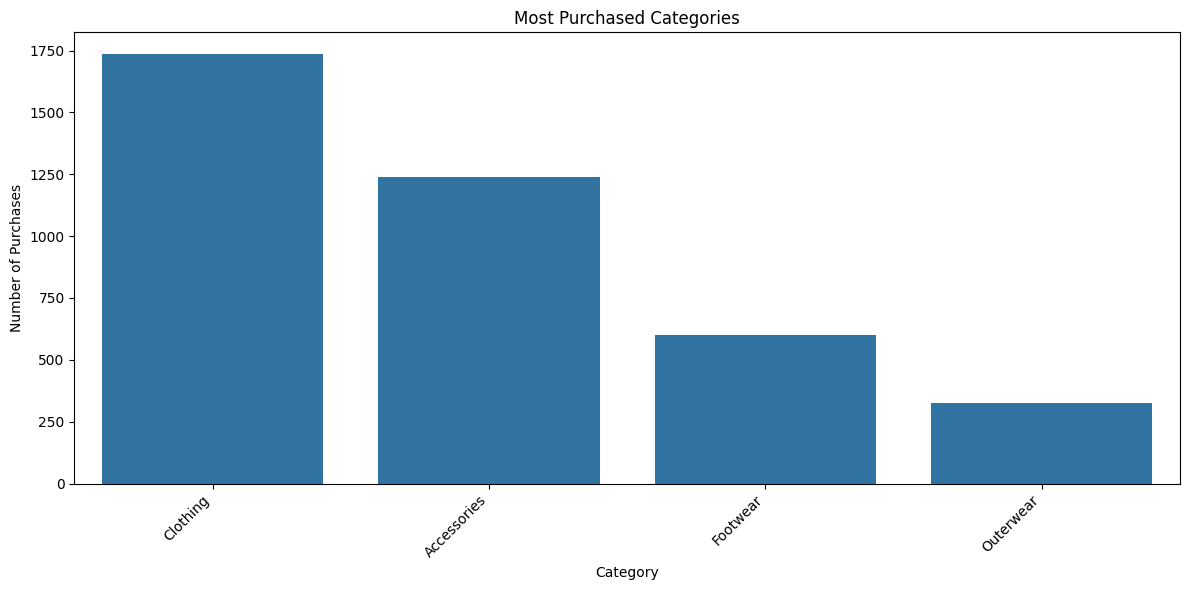

In [70]:
most_purchased_category = df['category'].value_counts()
print("Most Purchased Categories:")
display(most_purchased_category)

plt.figure(figsize=(12, 6))
sns.barplot(x=most_purchased_category.index, y=most_purchased_category.values)
plt.title('Most Purchased Categories')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Kis category se highest revenue aa raha hai?

Revenue by Category:


,purchase_amount
category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


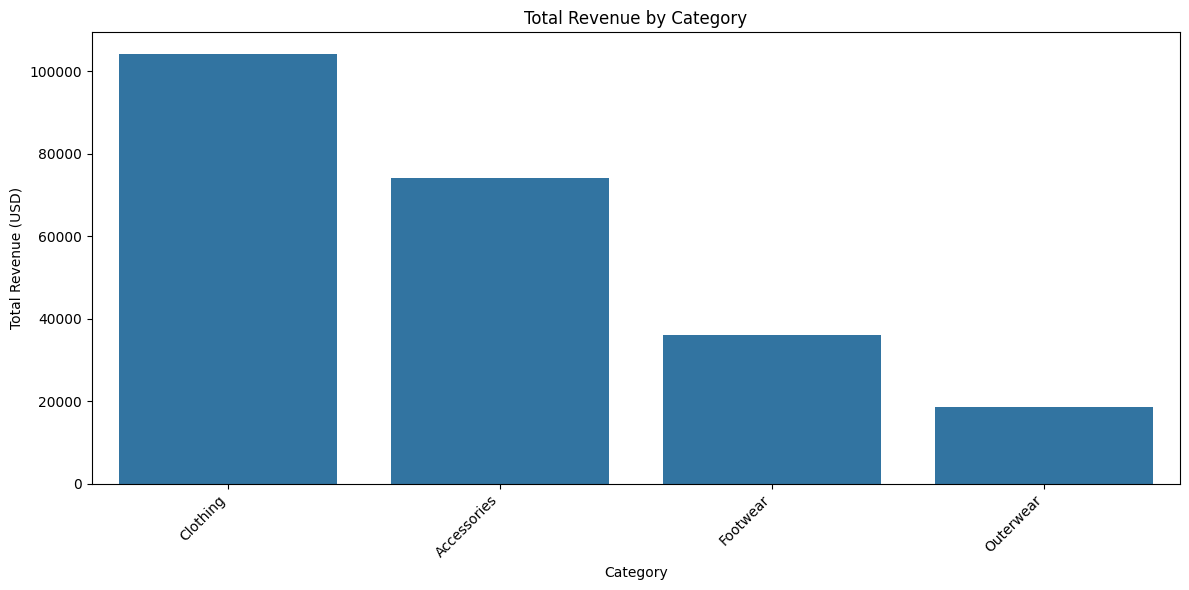

In [71]:
revenue_by_category = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Category:")
display(revenue_by_category)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values)
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Average order value/category kya hai?

### Subscription Impact on Spend ###


,mean,median,std
subscription_status,,,
False,59.865121,60.0,23.775199
True,59.491928,60.0,23.449914



### Discount Impact on Spend ###


,mean,median,std
discount_applied,,,
False,60.130454,60.0,23.740327
True,59.279070,60.0,23.610697



### Payment Method Impact on Spend ###


,mean,median
payment_method,,
Bank Transfer,59.712418,60.0
Cash,59.704478,60.0
Credit Card,60.074516,60.0
Debit Card,60.915094,61.0
PayPal,59.245199,59.0
Venmo,58.949527,58.0


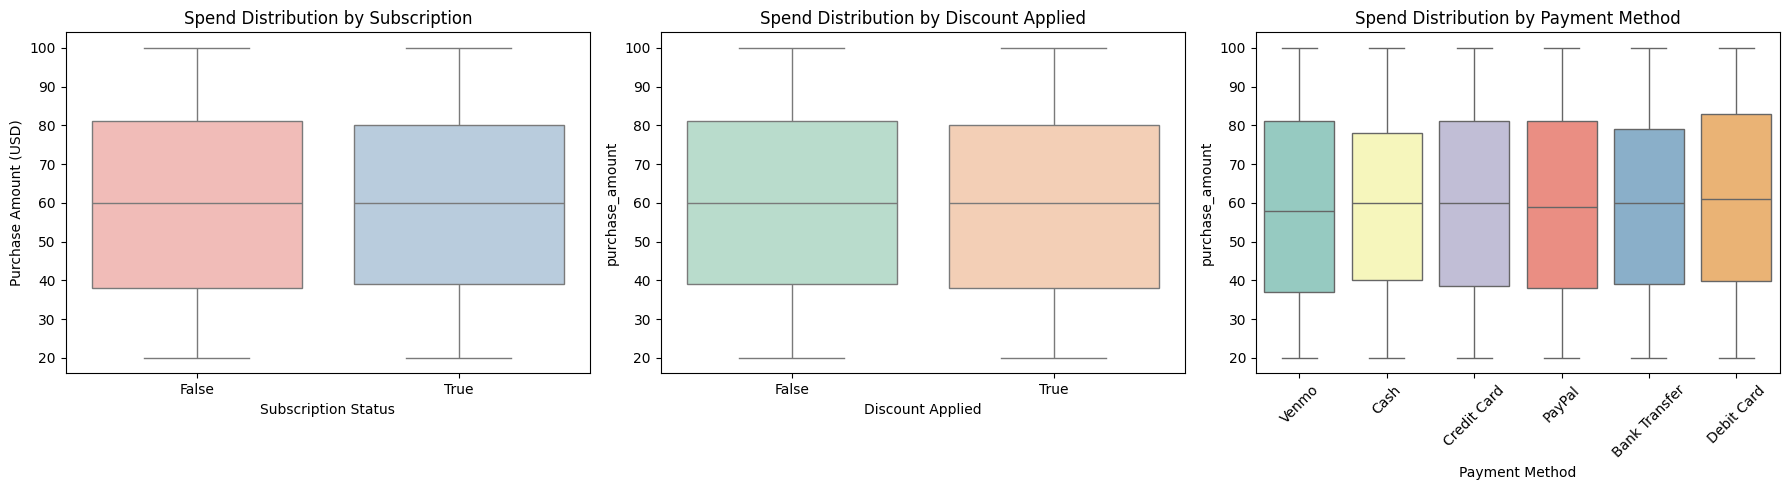

In [72]:
# 3. Subscription, Discount, and Payments spend behavior
sub_spend = df.groupby('subscription_status')['purchase_amount'].agg(['mean', 'median', 'std'])
disc_spend = df.groupby('discount_applied')['purchase_amount'].agg(['mean', 'median', 'std'])
pay_spend = df.groupby('payment_method')['purchase_amount'].agg(['mean', 'median'])

print("### Subscription Impact on Spend ###")
display(sub_spend)
print("\n### Discount Impact on Spend ###")
display(disc_spend)
print("\n### Payment Method Impact on Spend ###")
display(pay_spend)

# Visualizing Behavior
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='subscription_status', y='purchase_amount', palette='Pastel1', hue='subscription_status', legend=False)
plt.title('Spend Distribution by Subscription')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount (USD)')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='discount_applied', y='purchase_amount', palette='Pastel2', hue='discount_applied', legend=False)
plt.title('Spend Distribution by Discount Applied')
plt.xlabel('Discount Applied')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='payment_method', y='purchase_amount', palette='Set3', hue='payment_method', legend=False)
plt.title('Spend Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Purchase Amount by Category:


,purchase_amount
category,
Footwear,60.255426
Clothing,60.025331
Accessories,59.838710
Outerwear,57.172840


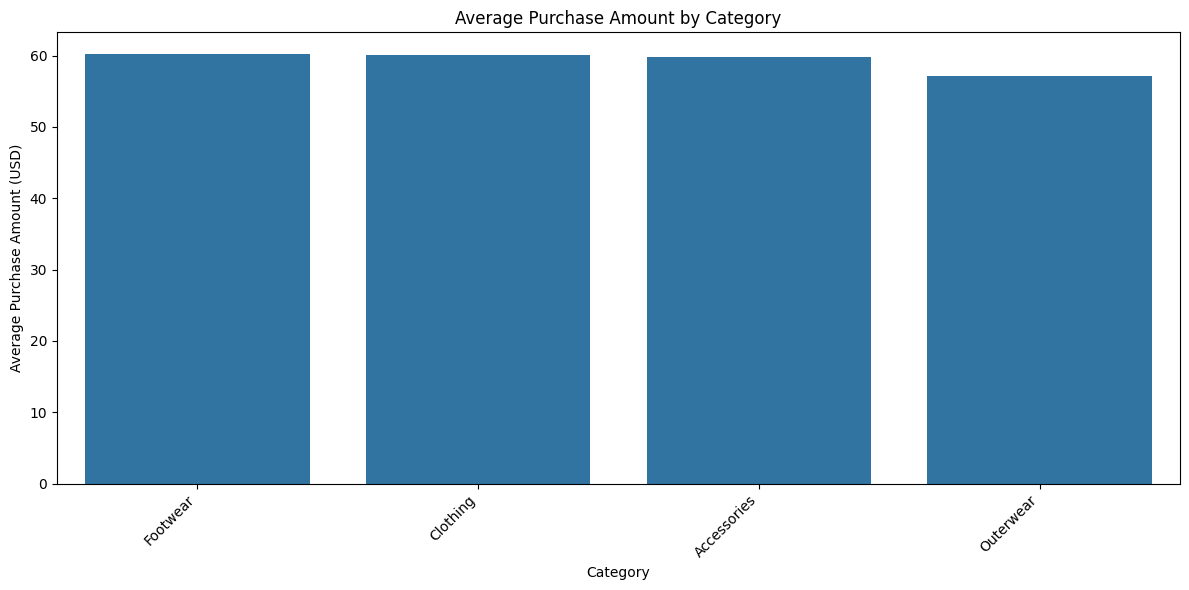

In [73]:
avg_order_value_by_category = df.groupby('category')['purchase_amount'].mean().sort_values(ascending=False)
print("Average Purchase Amount by Category:")
display(avg_order_value_by_category)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_order_value_by_category.index, y=avg_order_value_by_category.values)
plt.title('Average Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Purchase Amount (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Item Purchased Analysis

#### Top 10 most purchased products

Top 10 Most Purchased Items:


,count
item_purchased,
Blouse,171
Pants,171
Jewelry,171
Shirt,169
Dress,166
Sweater,164
Jacket,163
Coat,161
Sunglasses,161


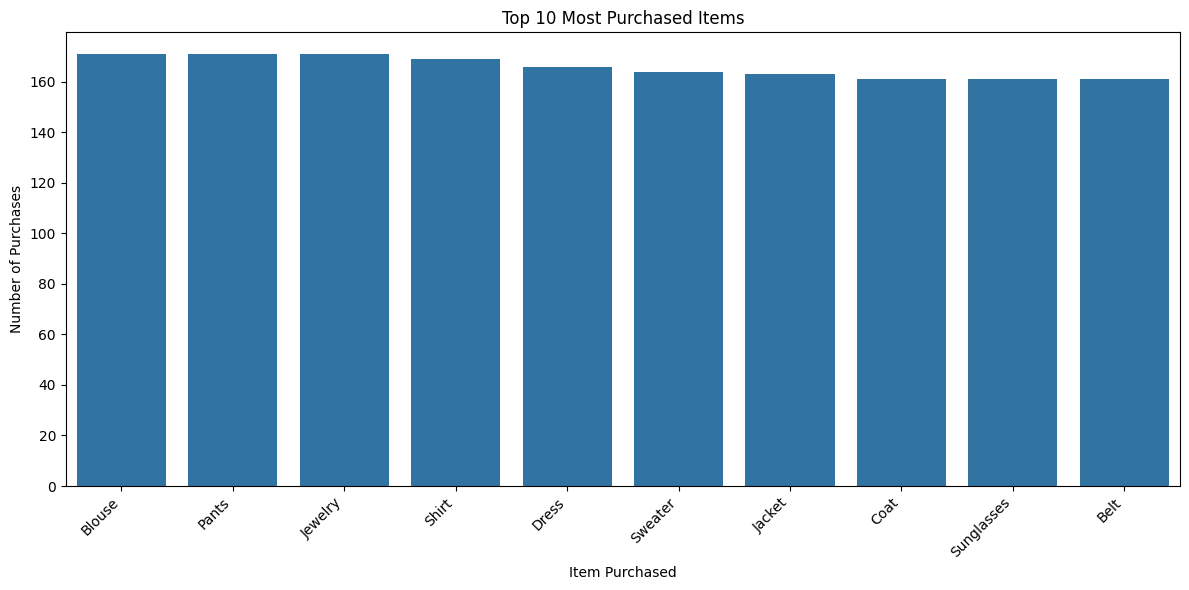

In [74]:
top_10_items = df['item_purchased'].value_counts().head(10)
print("Top 10 Most Purchased Items:")
display(top_10_items)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_items.index, y=top_10_items.values)
plt.title('Top 10 Most Purchased Items')
plt.xlabel('Item Purchased')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Top products by revenue

Top 10 Products by Revenue:


,purchase_amount
item_purchased,
Blouse,10410
Shirt,10332
Dress,10320
Pants,10090
Jewelry,10010
Sunglasses,9649
Belt,9635
Scarf,9561
Sweater,9462


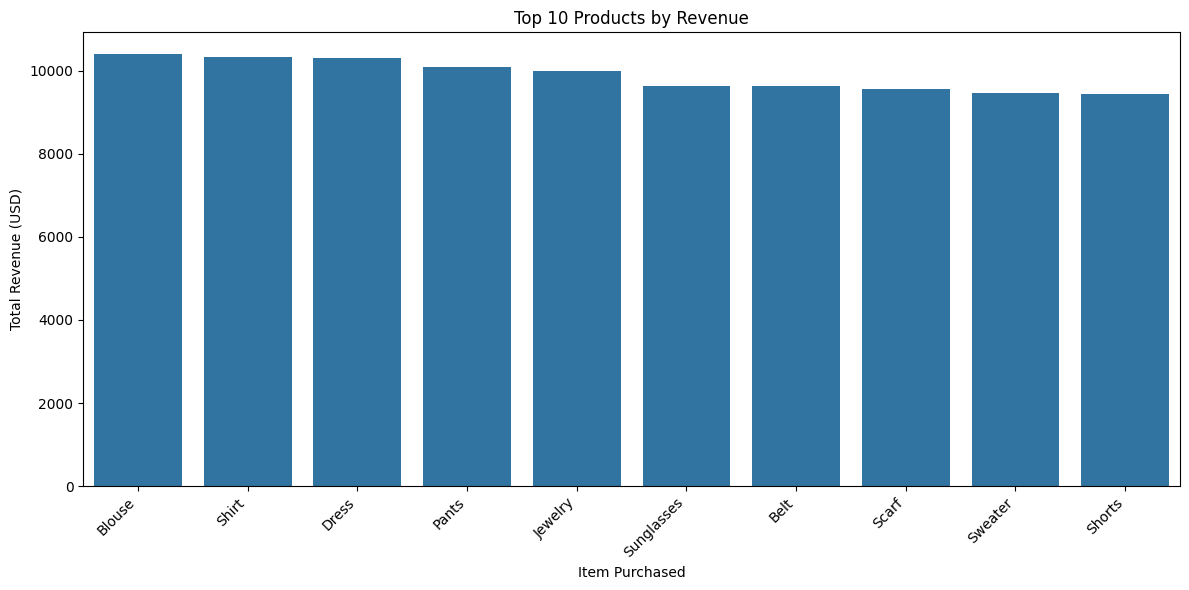

In [75]:
top_revenue_items = df.groupby('item_purchased')['purchase_amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Revenue:")
display(top_revenue_items)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_revenue_items.index, y=top_revenue_items.values)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Item Purchased')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Lowest performing products (least purchased)

10 Least Purchased Items:


,count
item_purchased,
Hat,154
Handbag,153
Hoodie,151
Shoes,150
T-shirt,147
Sneakers,145
Boots,144
Backpack,143
Gloves,140


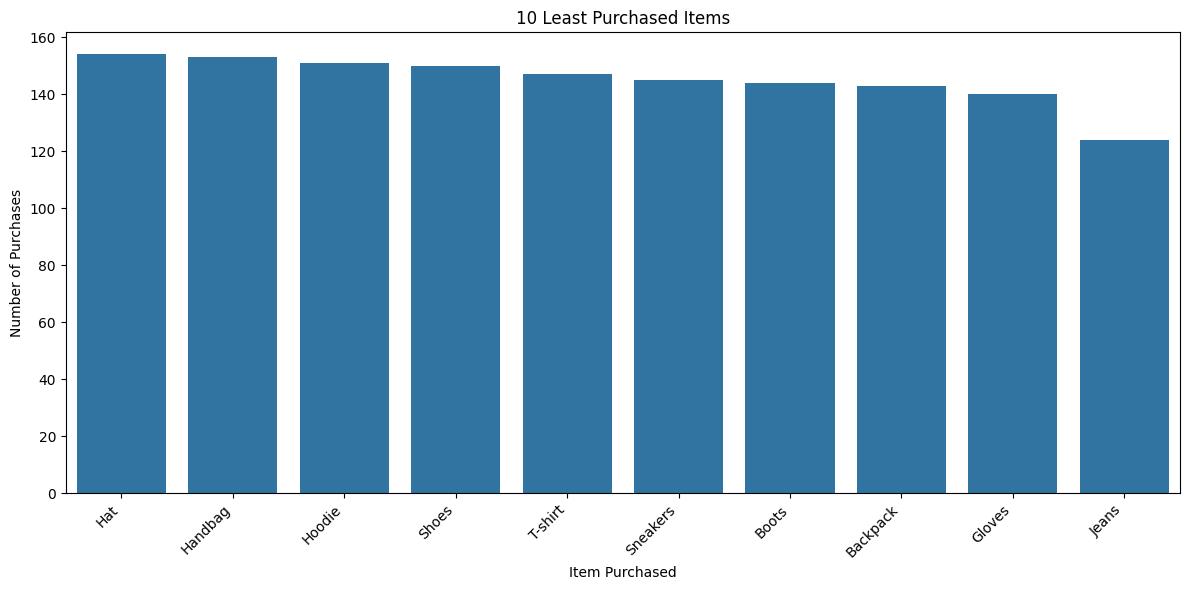

In [76]:
lowest_performing_items = df['item_purchased'].value_counts().tail(10)
print("10 Least Purchased Items:")
display(lowest_performing_items)

plt.figure(figsize=(12, 6))
sns.barplot(x=lowest_performing_items.index, y=lowest_performing_items.values)
plt.title('10 Least Purchased Items')
plt.xlabel('Item Purchased')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Size Analysis

#### S / M / L / XL distribution

Size Distribution:


,count
size,
M,1755
L,1053
S,663
XL,429


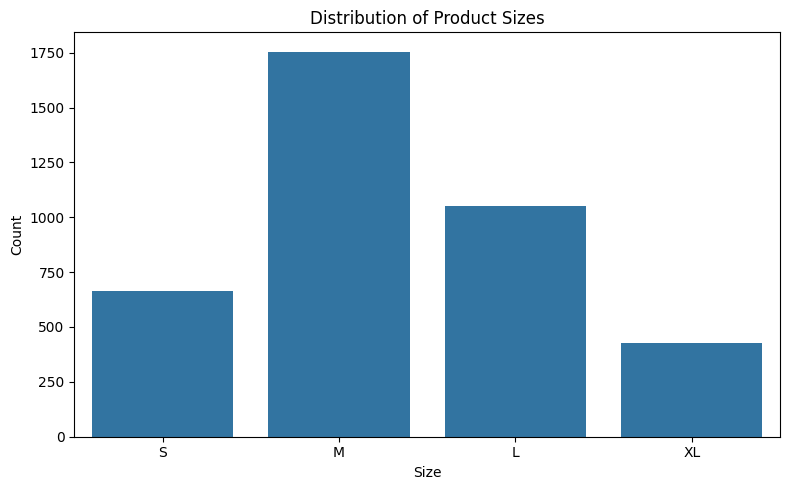

In [77]:
size_distribution = df['size'].value_counts()
print("Size Distribution:")
display(size_distribution)

plt.figure(figsize=(8, 5))
sns.barplot(x=size_distribution.index, y=size_distribution.values, order=['S', 'M', 'L', 'XL'])
plt.title('Distribution of Product Sizes')
plt.xlabel('Size')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Color Analysis

#### Most popular colors

Top 10 Most Popular Colors:


,count
color,
Olive,177
Yellow,174
Silver,173
Teal,172
Green,169
Black,167
Cyan,166
Violet,166
Gray,159


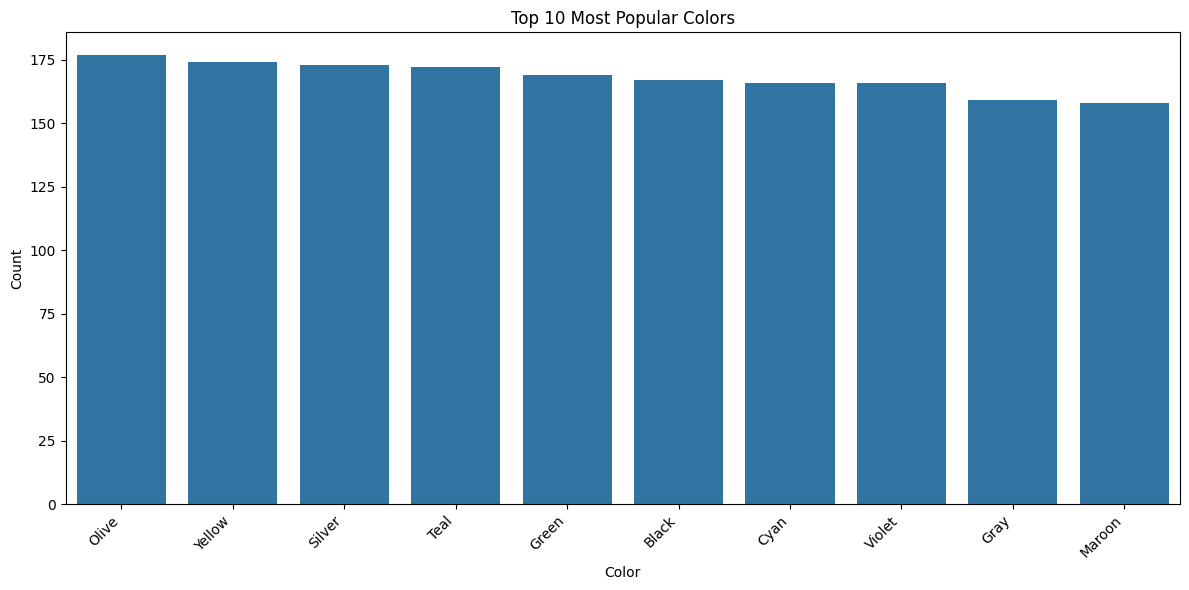

In [78]:
popular_colors = df['color'].value_counts().head(10)
print("Top 10 Most Popular Colors:")
display(popular_colors)

plt.figure(figsize=(12, 6))
sns.barplot(x=popular_colors.index, y=popular_colors.values)
plt.title('Top 10 Most Popular Colors')
plt.xlabel('Color')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Sales / Revenue Analysis

Is section mein hum company ke sales aur revenue ka gehrai se vishleshan karenge.

### Overall Revenue Statistics

Sabse pehle, hum kuch buniyadi revenue statistics calculate karenge:

In [79]:
total_revenue = df['purchase_amount'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

average_purchase_amount = df['purchase_amount'].mean()
print(f"Average Purchase Amount: ${average_purchase_amount:,.2f}")

minimum_purchase = df['purchase_amount'].min()
print(f"Minimum Purchase: ${minimum_purchase:,.2f}")

maximum_purchase = df['purchase_amount'].max()
print(f"Maximum Purchase: ${maximum_purchase:,.2f}")

median_purchase = df['purchase_amount'].median()
print(f"Median Purchase: ${median_purchase:,.2f}")

Total Revenue: $233,081.00
Average Purchase Amount: $59.76
Minimum Purchase: $20.00
Maximum Purchase: $100.00
Median Purchase: $60.00


### Revenue Analysis by Category

Ab hum category ke hisab se revenue ka vishleshan karenge.

Revenue by Category:


,purchase_amount
category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


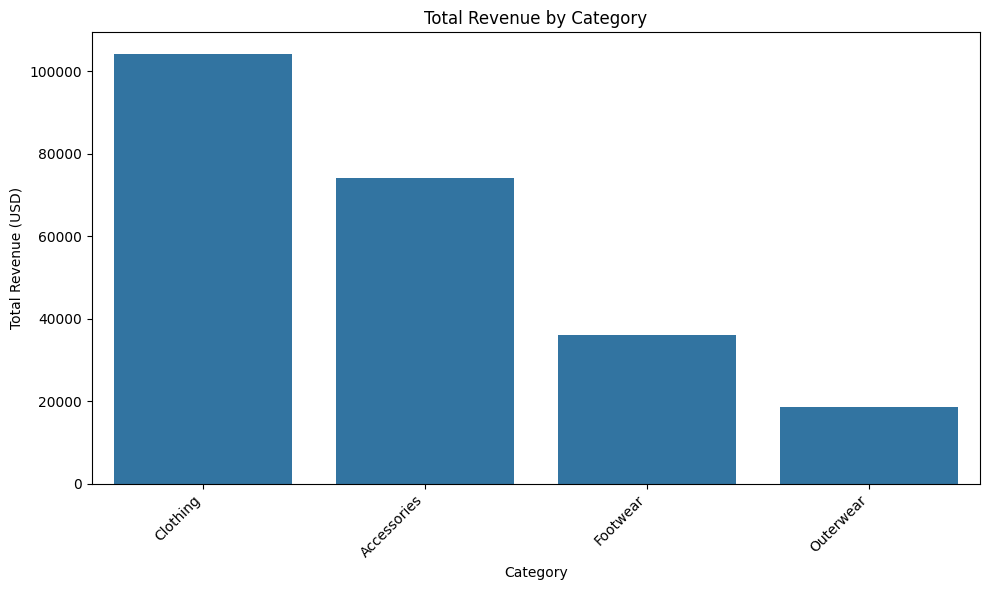

In [80]:
revenue_by_category = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Category:")
display(revenue_by_category)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values)
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Revenue Analysis by Gender

Ab hum gender ke hisab se revenue ka vishleshan karenge.

Revenue by Gender:


,purchase_amount
gender,
Male,157890
Female,75191


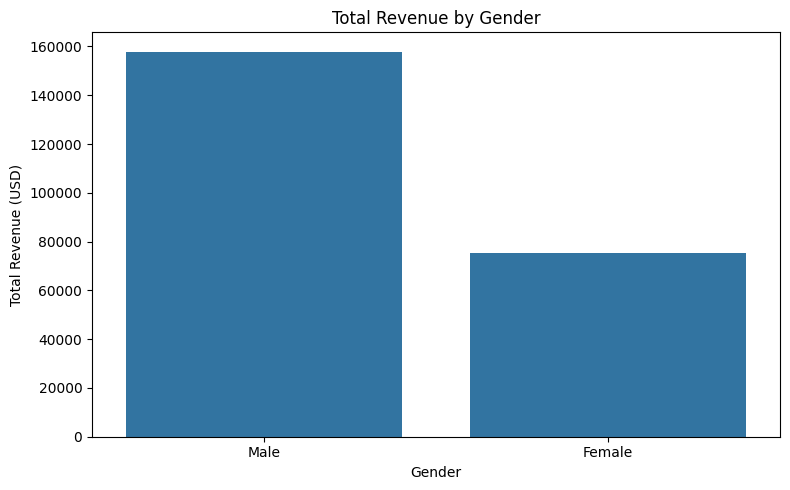

In [81]:
revenue_by_gender = df.groupby('gender')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Gender:")
display(revenue_by_gender)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_gender.index, y=revenue_by_gender.values)
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Revenue Analysis by Location

Ab hum customer ke location ke hisab se revenue ka vishleshan karenge.

Top 10 Locations by Revenue:


,purchase_amount
location,
Montana,5784
Illinois,5617
California,5605
Idaho,5587
Nevada,5514
Alabama,5261
New York,5257
North Dakota,5220
West Virginia,5174


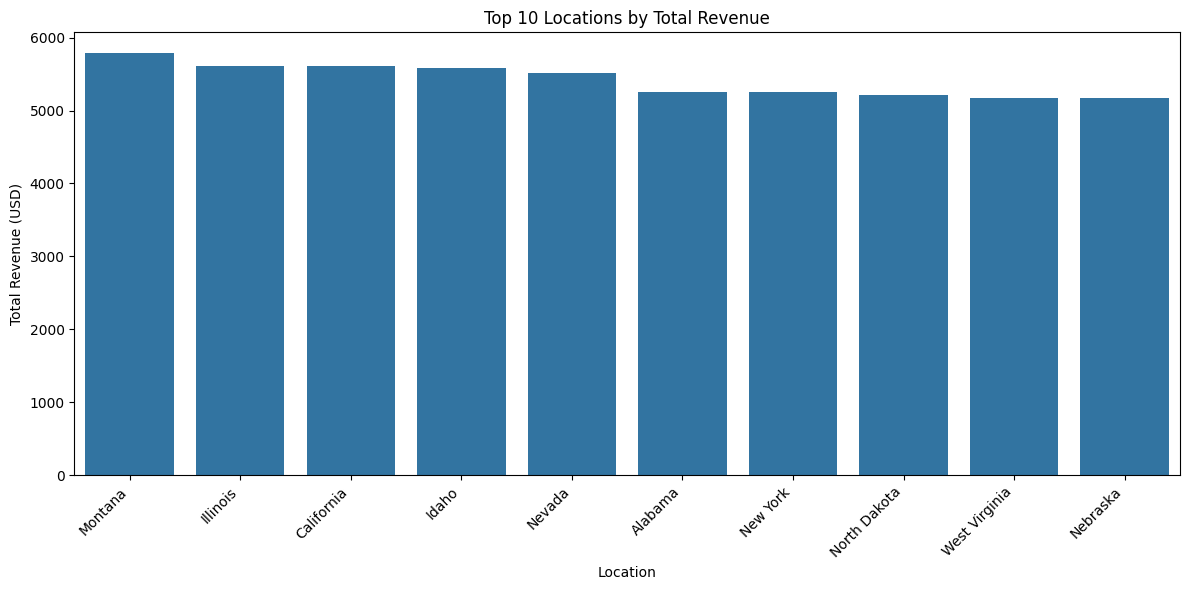

In [82]:
revenue_by_location = df.groupby('location')['purchase_amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Locations by Revenue:")
display(revenue_by_location)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_location.index, y=revenue_by_location.values)
plt.title('Top 10 Locations by Total Revenue')
plt.xlabel('Location')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Revenue Analysis by Season

Ab hum season ke hisab se revenue ka vishleshan karenge.

Revenue by Season:


,purchase_amount
season,
Fall,60018
Spring,58679
Winter,58607
Summer,55777


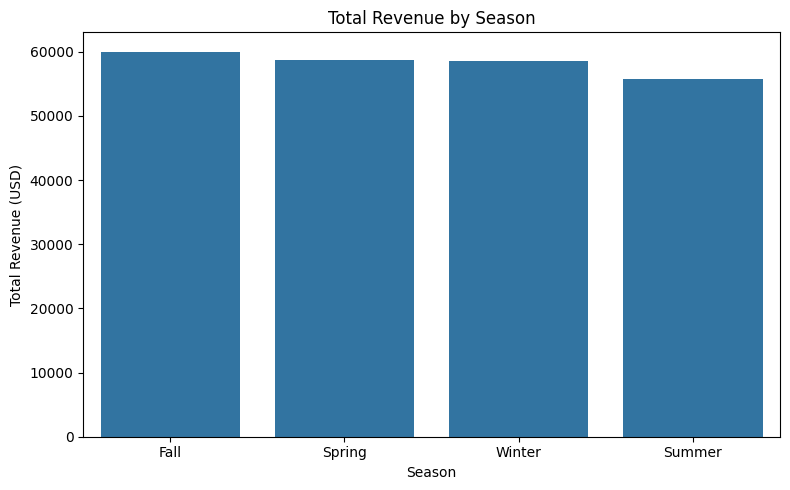

In [83]:
revenue_by_season = df.groupby('season')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Season:")
display(revenue_by_season)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_season.index, y=revenue_by_season.values)
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Revenue Analysis by Age Group

Ab hum age group ke hisab se revenue ka vishleshan karenge.

Revenue by Age Group:


/tmp/ipykernel_856/3594823412.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=False)


,purchase_amount
age_group,
56+,69590
26-35,45400
46-55,45370
36-45,43463
18-25,29258


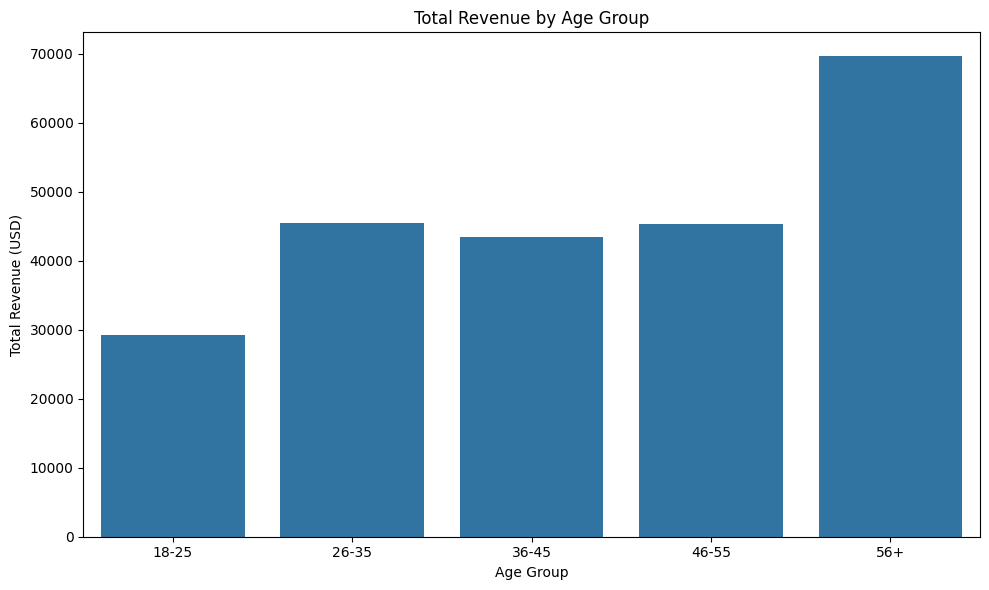

In [84]:
revenue_by_age_group = df.groupby('age_group')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Age Group:")
display(revenue_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_age_group.index, y=revenue_by_age_group.values)
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Revenue Analysis by Subscription Status

Ab hum subscription status ke hisab se revenue ka vishleshan karenge.

Revenue by Subscription Status:


,purchase_amount
subscription_status,
False,170436
True,62645


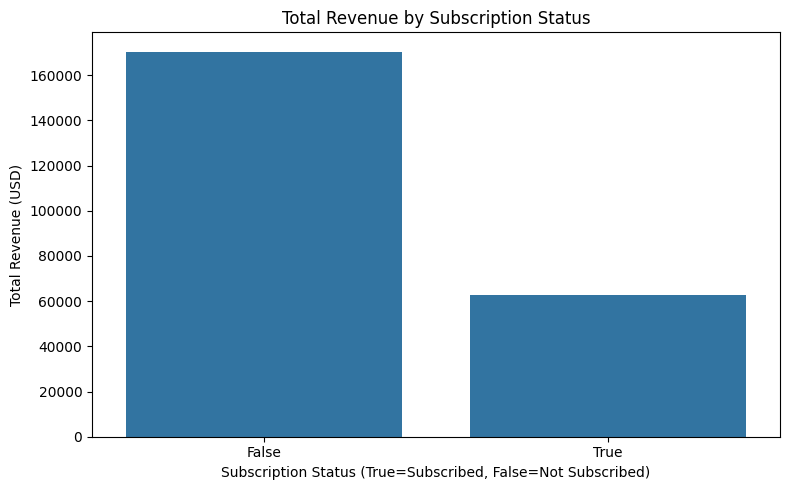

In [85]:
revenue_by_subscription = df.groupby('subscription_status')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Subscription Status:")
display(revenue_by_subscription)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_subscription.index, y=revenue_by_subscription.values)
plt.title('Total Revenue by Subscription Status')
plt.xlabel('Subscription Status (True=Subscribed, False=Not Subscribed)')
plt.ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.show()

### Revenue Analysis by Payment Method

Ab hum payment method ke hisab se revenue ka vishleshan karenge.

Revenue by Payment Method:


,purchase_amount
payment_method,
Credit Card,40310
PayPal,40109
Cash,40002
Debit Card,38742
Venmo,37374
Bank Transfer,36544


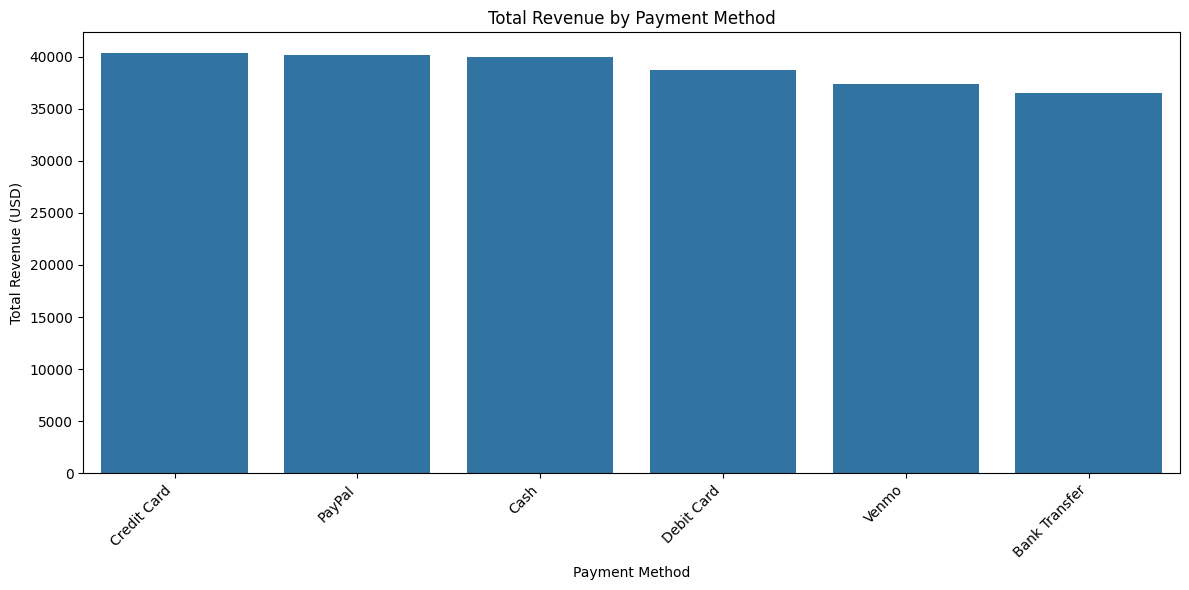

In [86]:
revenue_by_payment_method = df.groupby('payment_method')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue by Payment Method:")
display(revenue_by_payment_method)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_payment_method.index, y=revenue_by_payment_method.values)
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1. Sales and Average Purchase by Season ###


,Total Revenue (USD),Average Purchase (USD),Number of Purchases
season,,,
Fall,60018,61.556923,975
Spring,58679,58.737738,999
Winter,58607,60.357364,971
Summer,55777,58.405236,955


/tmp/ipykernel_856/2472381168.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_stats.index, y='Total Revenue (USD)', data=season_stats, palette='viridis')
/tmp/ipykernel_856/2472381168.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_stats.index, y='Average Purchase (USD)', data=season_stats, palette='coolwarm')


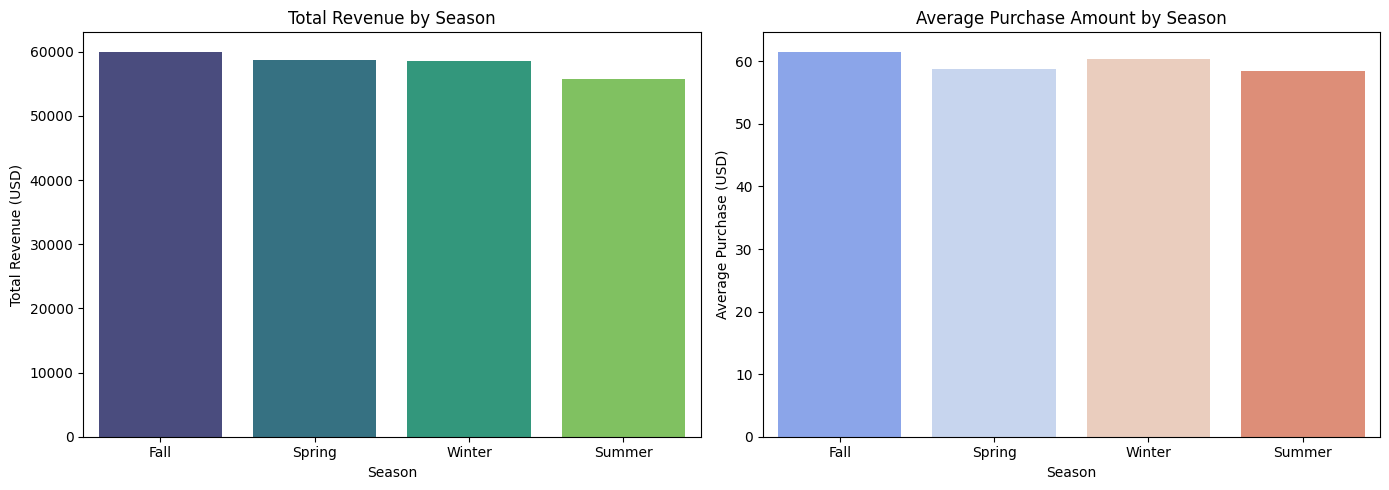


### 2. Category Popularity by Season (Season × Category) ###
Purchase Count (Season x Category):


category,Accessories,Clothing,Footwear,Outerwear
season,,,,
Fall,324,427,136,88
Spring,301,454,163,81
Summer,312,408,160,75
Winter,303,448,140,80


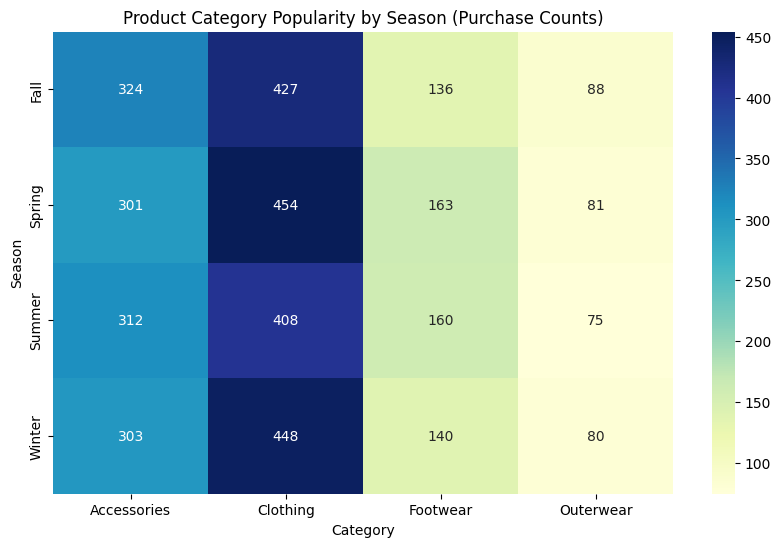


Revenue (Season x Category):


category,Accessories,Clothing,Footwear,Outerwear
season,,,,
Fall,19874,26220,8665,5259
Spring,17007,27692,9555,4425
Summer,19028,23078,9393,4278
Winter,18291,27274,8480,4562


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("### 1. Sales and Average Purchase by Season ###")
season_stats = df.groupby('season')['purchase_amount'].agg(['sum', 'mean', 'count']).rename(columns={
    'sum': 'Total Revenue (USD)',
    'mean': 'Average Purchase (USD)',
    'count': 'Number of Purchases'
}).sort_values(by='Total Revenue (USD)', ascending=False)

display(season_stats)

# Visualization of Total Revenue and Average Purchase by Season
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=season_stats.index, y='Total Revenue (USD)', data=season_stats, palette='viridis')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')

plt.subplot(1, 2, 2)
sns.barplot(x=season_stats.index, y='Average Purchase (USD)', data=season_stats, palette='coolwarm')
plt.title('Average Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Average Purchase (USD)')

plt.tight_layout()
plt.show()

print("\n### 2. Category Popularity by Season (Season × Category) ###")
# Pivot table to see the count of items purchased for each Category in each Season
season_category_pivot = pd.crosstab(df['season'], df['category'])
print("Purchase Count (Season x Category):")
display(season_category_pivot)

# Visualization: Heatmap of Season x Category Popularity
plt.figure(figsize=(10, 6))
sns.heatmap(season_category_pivot, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title('Product Category Popularity by Season (Purchase Counts)')
plt.xlabel('Category')
plt.ylabel('Season')
plt.show()

# Also let's check Revenue generated by Category in each Season
season_category_revenue = df.pivot_table(index='season', columns='category', values='purchase_amount', aggfunc='sum')
print("\nRevenue (Season x Category):")
display(season_category_revenue)


### 10. Subscription Analysis
In this section, we analyze the impact of having a subscription. We compare **Subscribers (True)** vs **Non-subscribers (False)** across the following metrics:
- Customer count
- Total revenue
- Average purchase amount
- Average review rating
- Previous purchases

### Subscription Analysis Summary Table ###


,customer_count,total_revenue,average_purchase,average_rating,average_previous_purchases
subscription_status,,,,,
Non-Subscriber,2847,170436,59.865121,3.751019,25.080436
Subscriber,1053,62645,59.491928,3.747485,26.084520


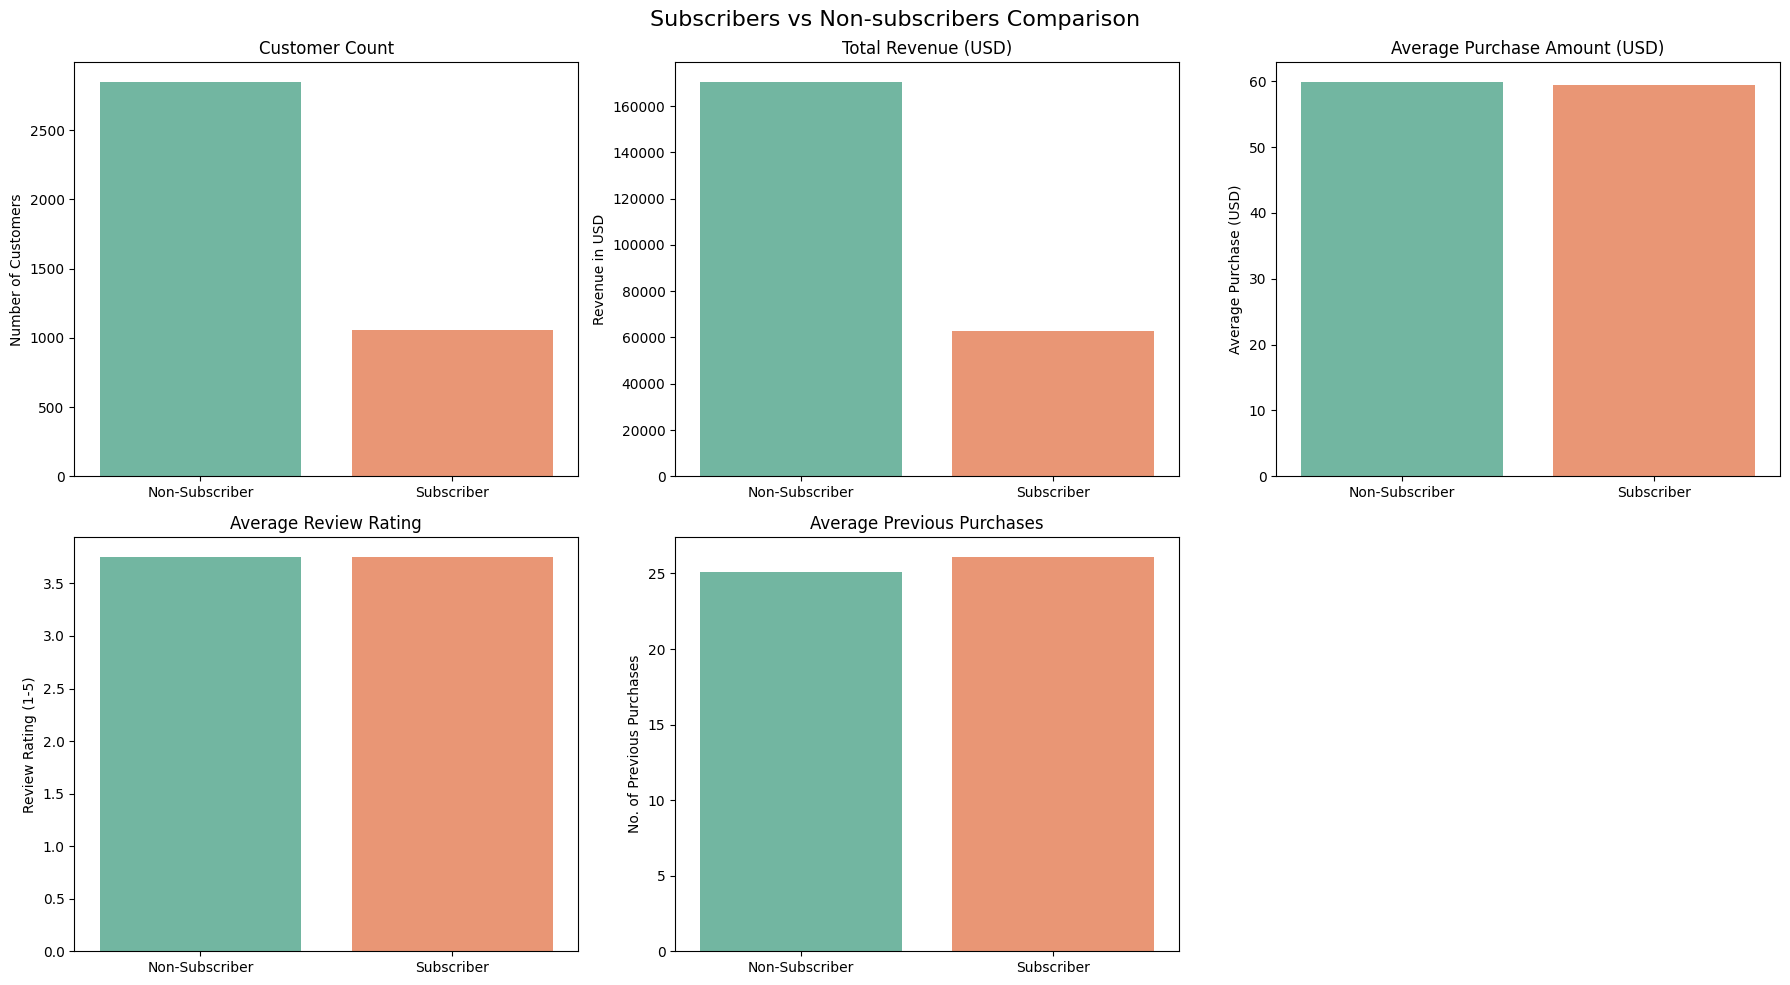

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by subscription_status to calculate key metrics
subscription_analysis = df.groupby('subscription_status').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean'),
    average_rating=('review_rating', 'mean'),
    average_previous_purchases=('previous_purchases', 'mean')
).rename(index={True: 'Subscriber', False: 'Non-Subscriber'})

print("### Subscription Analysis Summary Table ###")
display(subscription_analysis)

# Visualizing the key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Subscribers vs Non-subscribers Comparison', fontsize=16)

# 1. Customer Count
sns.barplot(ax=axes[0, 0], x=subscription_analysis.index, y='customer_count', data=subscription_analysis, palette='Set2', hue=subscription_analysis.index, legend=False)
axes[0, 0].set_title('Customer Count')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_xlabel('')

# 2. Total Revenue
sns.barplot(ax=axes[0, 1], x=subscription_analysis.index, y='total_revenue', data=subscription_analysis, palette='Set2', hue=subscription_analysis.index, legend=False)
axes[0, 1].set_title('Total Revenue (USD)')
axes[0, 1].set_ylabel('Revenue in USD')
axes[0, 1].set_xlabel('')

# 3. Average Purchase Amount
sns.barplot(ax=axes[0, 2], x=subscription_analysis.index, y='average_purchase', data=subscription_analysis, palette='Set2', hue=subscription_analysis.index, legend=False)
axes[0, 2].set_title('Average Purchase Amount (USD)')
axes[0, 2].set_ylabel('Average Purchase (USD)')
axes[0, 2].set_xlabel('')

# 4. Average Review Rating
sns.barplot(ax=axes[1, 0], x=subscription_analysis.index, y='average_rating', data=subscription_analysis, palette='Set2', hue=subscription_analysis.index, legend=False)
axes[1, 0].set_title('Average Review Rating')
axes[1, 0].set_ylabel('Review Rating (1-5)')
axes[1, 0].set_xlabel('')

# 5. Average Previous Purchases
sns.barplot(ax=axes[1, 1], x=subscription_analysis.index, y='average_previous_purchases', data=subscription_analysis, palette='Set2', hue=subscription_analysis.index, legend=False)
axes[1, 1].set_title('Average Previous Purchases')
axes[1, 1].set_ylabel('No. of Previous Purchases')
axes[1, 1].set_xlabel('')

# Hide the empty 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### 11. Discount & Promo Code Analysis

In this section, we analyze the impact of incentives:
1. **Discount Applied** (True vs. False)
2. **Promo Code Used** (True vs. False)

We will measure:
- Average purchase amount
- Total revenue
- Number of customers

### Discount Applied Summary ###


,customer_count,total_revenue,average_purchase
discount_applied,,,
Discount (No),2223,133670,60.130454
Discount (Yes),1677,99411,59.279070



### Promo Code Used Summary ###


,customer_count,total_revenue,average_purchase
promo_code_used,,,
Promo Used (No),2223,133670,60.130454
Promo Used (Yes),1677,99411,59.279070


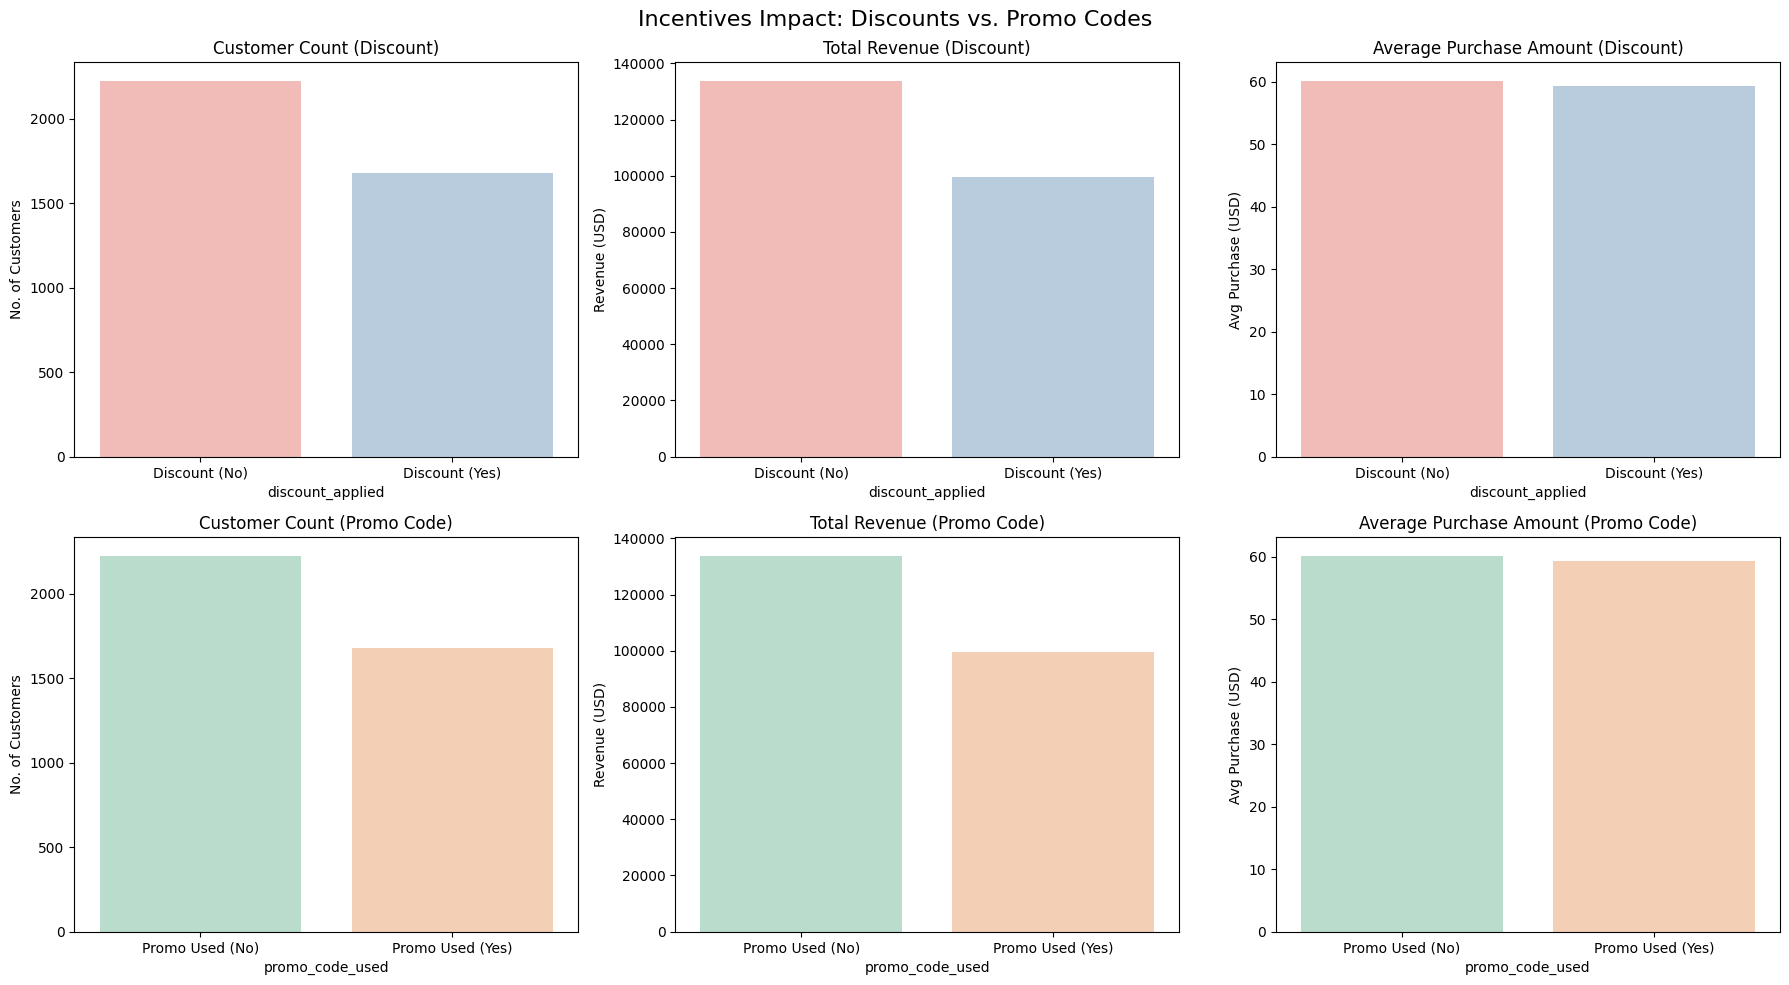

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Discount Applied Analysis
discount_stats = df.groupby('discount_applied').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean')
).rename(index={True: 'Discount (Yes)', False: 'Discount (No)'})

print("### Discount Applied Summary ###")
display(discount_stats)

# 2. Promo Code Used Analysis
promo_stats = df.groupby('promo_code_used').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean')
).rename(index={True: 'Promo Used (Yes)', False: 'Promo Used (No)'})

print("\n### Promo Code Used Summary ###")
display(promo_stats)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Incentives Impact: Discounts vs. Promo Codes', fontsize=16)

# Discounts Plots
sns.barplot(ax=axes[0, 0], x=discount_stats.index, y='customer_count', data=discount_stats, palette='Pastel1', hue=discount_stats.index, legend=False)
axes[0, 0].set_title('Customer Count (Discount)')
axes[0, 0].set_ylabel('No. of Customers')

sns.barplot(ax=axes[0, 1], x=discount_stats.index, y='total_revenue', data=discount_stats, palette='Pastel1', hue=discount_stats.index, legend=False)
axes[0, 1].set_title('Total Revenue (Discount)')
axes[0, 1].set_ylabel('Revenue (USD)')

sns.barplot(ax=axes[0, 2], x=discount_stats.index, y='average_purchase', data=discount_stats, palette='Pastel1', hue=discount_stats.index, legend=False)
axes[0, 2].set_title('Average Purchase Amount (Discount)')
axes[0, 2].set_ylabel('Avg Purchase (USD)')

# Promo Codes Plots
sns.barplot(ax=axes[1, 0], x=promo_stats.index, y='customer_count', data=promo_stats, palette='Pastel2', hue=promo_stats.index, legend=False)
axes[1, 0].set_title('Customer Count (Promo Code)')
axes[1, 0].set_ylabel('No. of Customers')

sns.barplot(ax=axes[1, 1], x=promo_stats.index, y='total_revenue', data=promo_stats, palette='Pastel2', hue=promo_stats.index, legend=False)
axes[1, 1].set_title('Total Revenue (Promo Code)')
axes[1, 1].set_ylabel('Revenue (USD)')

sns.barplot(ax=axes[1, 2], x=promo_stats.index, y='average_purchase', data=promo_stats, palette='Pastel2', hue=promo_stats.index, legend=False)
axes[1, 2].set_title('Average Purchase Amount (Promo Code)')
axes[1, 2].set_ylabel('Avg Purchase (USD)')

plt.tight_layout()
plt.show()

### 12. Payment Method Analysis

In this section, we analyze how different payment methods impact customer purchase behavior:
1. **Most Used Payment Method** (Transaction Count)
2. **Highest Revenue Generating Payment Method** (Total Revenue)
3. **Average Purchase Amount** by Payment Method

### Payment Method Summary Table ###


,transaction_count,total_revenue,average_purchase
payment_method,,,
PayPal,677,40109,59.245199
Credit Card,671,40310,60.074516
Cash,670,40002,59.704478
Debit Card,636,38742,60.915094
Venmo,634,37374,58.949527
Bank Transfer,612,36544,59.712418



1. Most Used Payment Method: PayPal (677 transactions)
2. Highest Revenue Payment Method: Credit Card ($40,310.00)


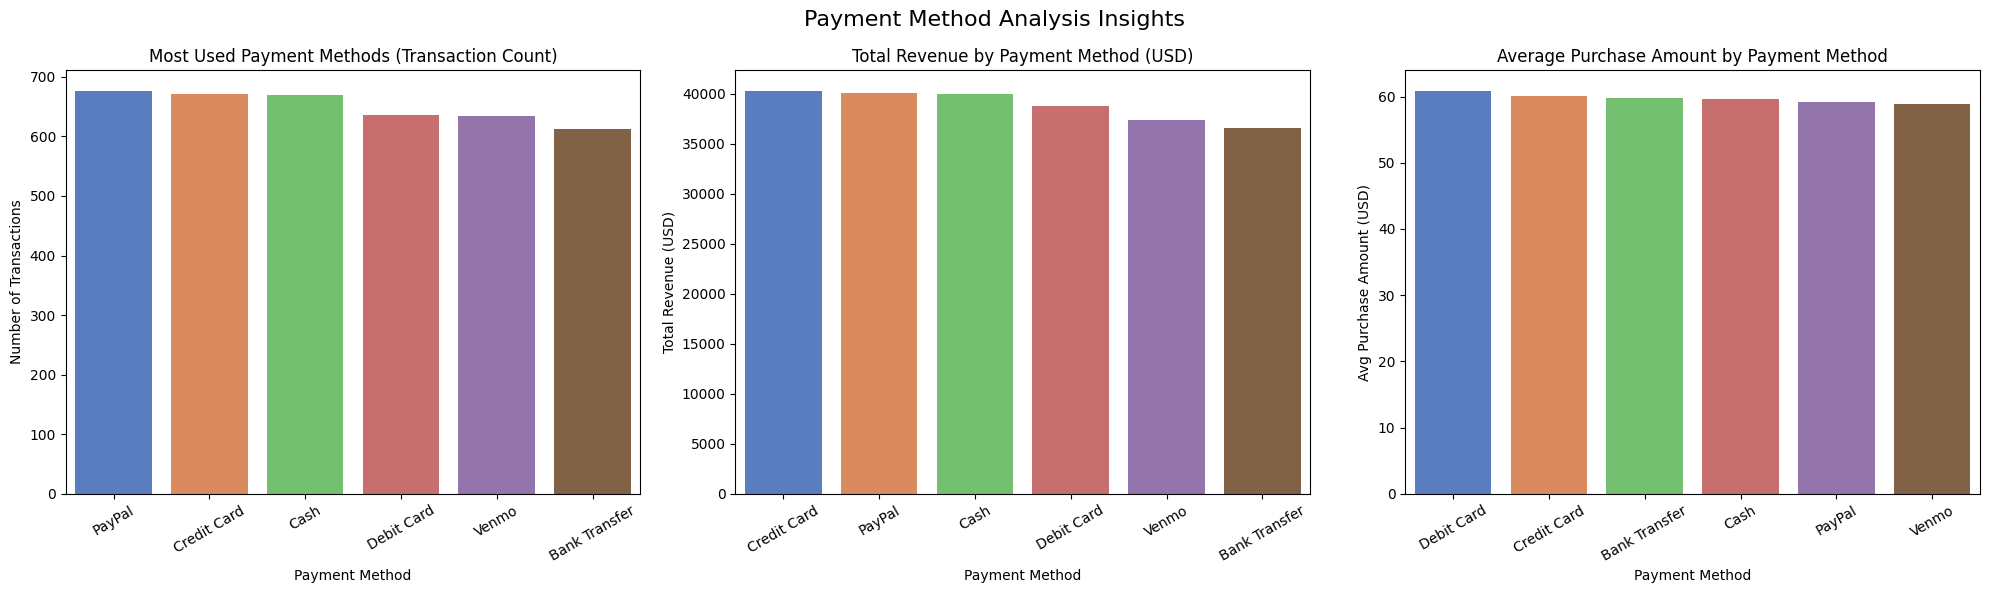

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by payment_method to calculate count, sum, and average of purchase_amount
payment_stats = df.groupby('payment_method').agg(
    transaction_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean')
).sort_values(by='transaction_count', ascending=False)

print("### Payment Method Summary Table ###")
display(payment_stats)

# Finding answers to specific questions
most_used = payment_stats['transaction_count'].idxmax()
most_used_count = payment_stats['transaction_count'].max()

highest_revenue_method = payment_stats['total_revenue'].idxmax()
highest_revenue_val = payment_stats['total_revenue'].max()

print(f"\n1. Most Used Payment Method: {most_used} ({most_used_count} transactions)")
print(f"2. Highest Revenue Payment Method: {highest_revenue_method} (${highest_revenue_val:,.2f})")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Payment Method Analysis Insights', fontsize=16)

# Plot 1: Most Used Payment Methods
sns.barplot(ax=axes[0], x=payment_stats.index, y='transaction_count', data=payment_stats, palette='muted', hue=payment_stats.index, legend=False)
axes[0].set_title('Most Used Payment Methods (Transaction Count)')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Total Revenue by Payment Method
payment_revenue_sorted = payment_stats.sort_values(by='total_revenue', ascending=False)
sns.barplot(ax=axes[1], x=payment_revenue_sorted.index, y='total_revenue', data=payment_revenue_sorted, palette='muted', hue=payment_revenue_sorted.index, legend=False)
axes[1].set_title('Total Revenue by Payment Method (USD)')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Average Purchase Amount by Payment Method
payment_avg_sorted = payment_stats.sort_values(by='average_purchase', ascending=False)
sns.barplot(ax=axes[2], x=payment_avg_sorted.index, y='average_purchase', data=payment_avg_sorted, palette='muted', hue=payment_avg_sorted.index, legend=False)
axes[2].set_title('Average Purchase Amount by Payment Method')
axes[2].set_xlabel('Payment Method')
axes[2].set_ylabel('Avg Purchase Amount (USD)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 13. Shipping Analysis

In this section, we analyze the impact of different shipping methods on customer behavior:
1. **Most Popular Shipping Method** (Transaction Count)
2. **Average Purchase Amount** by Shipping Type
3. **Express Shipping vs. Other Methods Spend Analysis** (Do Express/Next Day Air customers spend more?)

### Shipping Method Summary Table ###


,transaction_count,total_revenue,average_purchase
shipping_type,,,
Free Shipping,675,40777,60.410370
Standard,654,38233,58.460245
Store Pickup,650,38931,59.893846
Next Day Air,648,37993,58.631173
Express,646,39067,60.475232
2-Day Shipping,627,38080,60.733652



1. Most Popular Shipping Method: Free Shipping (675 transactions)
2. Average Purchase by Shipping Type: Sorted above in the summary table

### Express/Fast Shipping vs. Standard/Other Shipping Spend ###


,count,mean,sum
is_express_delivery,,,
Standard/Free/Pickup,1979,59.596261,117941
Express/Fast Shipping,1921,59.937533,115140


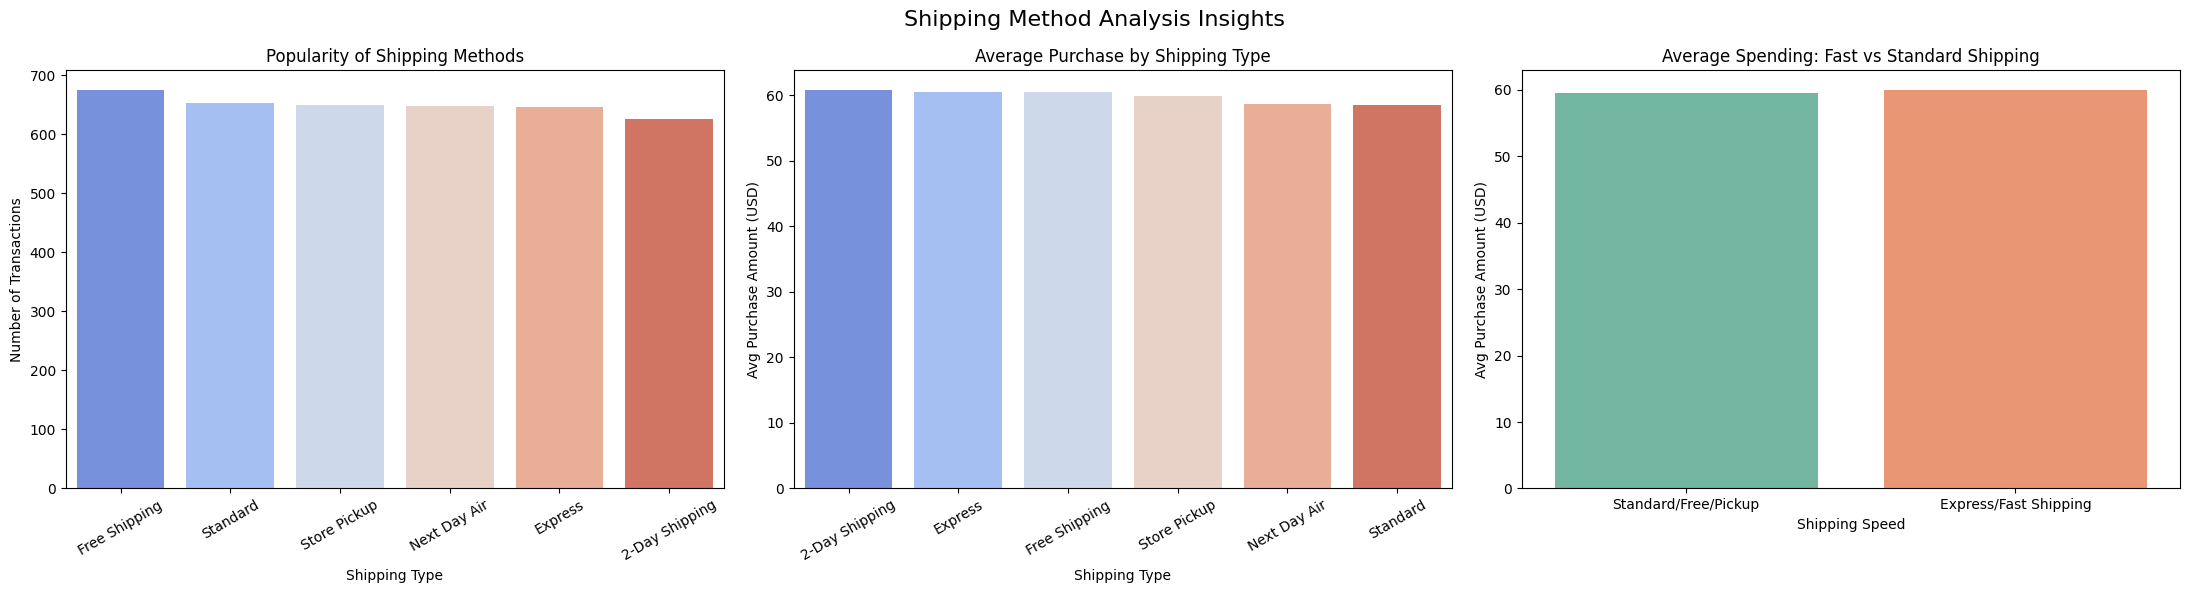

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by shipping_type to get counts and averages
shipping_stats = df.groupby('shipping_type').agg(
    transaction_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean')
).sort_values(by='transaction_count', ascending=False)

print("### Shipping Method Summary Table ###")
display(shipping_stats)

# Answering specific questions
most_popular_shipping = shipping_stats['transaction_count'].idxmax()
most_popular_count = shipping_stats['transaction_count'].max()

# Comparing Express group (Express, Next Day Air, 2-Day Shipping) vs Standard/Free group
express_types = ['Express', 'Next Day Air', '2-Day Shipping']
df['is_express_delivery'] = df['shipping_type'].isin(express_types)

express_comparison = df.groupby('is_express_delivery')['purchase_amount'].agg(['count', 'mean', 'sum']).rename(index={True: 'Express/Fast Shipping', False: 'Standard/Free/Pickup'})

print(f"\n1. Most Popular Shipping Method: {most_popular_shipping} ({most_popular_count} transactions)")
print(f"2. Average Purchase by Shipping Type: Sorted above in the summary table")

print("\n### Express/Fast Shipping vs. Standard/Other Shipping Spend ###")
display(express_comparison)

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Shipping Method Analysis Insights', fontsize=16)

# Plot 1: Popularity of Shipping Methods
sns.barplot(ax=axes[0], x=shipping_stats.index, y='transaction_count', data=shipping_stats, palette='coolwarm', hue=shipping_stats.index, legend=False)
axes[0].set_title('Popularity of Shipping Methods')
axes[0].set_xlabel('Shipping Type')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Average Purchase by Shipping Type
shipping_avg_sorted = shipping_stats.sort_values(by='average_purchase', ascending=False)
sns.barplot(ax=axes[1], x=shipping_avg_sorted.index, y='average_purchase', data=shipping_avg_sorted, palette='coolwarm', hue=shipping_avg_sorted.index, legend=False)
axes[1].set_title('Average Purchase by Shipping Type')
axes[1].set_xlabel('Shipping Type')
axes[1].set_ylabel('Avg Purchase Amount (USD)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Fast Shipping vs Standard Spend Comparison
sns.barplot(ax=axes[2], x=express_comparison.index, y='mean', data=express_comparison, palette='Set2', hue=express_comparison.index, legend=False)
axes[2].set_title('Average Spending: Fast vs Standard Shipping')
axes[2].set_xlabel('Shipping Speed')
axes[2].set_ylabel('Avg Purchase Amount (USD)')

plt.tight_layout()
plt.show()

### 14. Frequency of Purchases Analysis

In this section, we analyze customer purchasing behavior based on how frequently they shop:
1. **Most Frequent Customer Group** (Transaction Count)
2. **Highest Revenue Generating Frequency Group** (Total Revenue)
3. **Average Purchase Amount** by Frequency of Purchases

### Frequency of Purchases Summary Table ###


,transaction_count,total_revenue,average_purchase
frequency_of_purchases,,,
Every 3 Months,584,35088,60.082192
Annually,572,34419,60.173077
Quarterly,563,33771,59.984014
Monthly,553,32810,59.330922
Bi-Weekly,547,33200,60.694698
Fortnightly,542,32007,59.053506
Weekly,539,31786,58.972171



1. Most Frequent Customer Group: Every 3 Months (584 transactions)
2. Highest Revenue Generating Frequency Group: Every 3 Months ($35,088.00)
3. Average Purchase Amount by Frequency: Shown in the summary table above


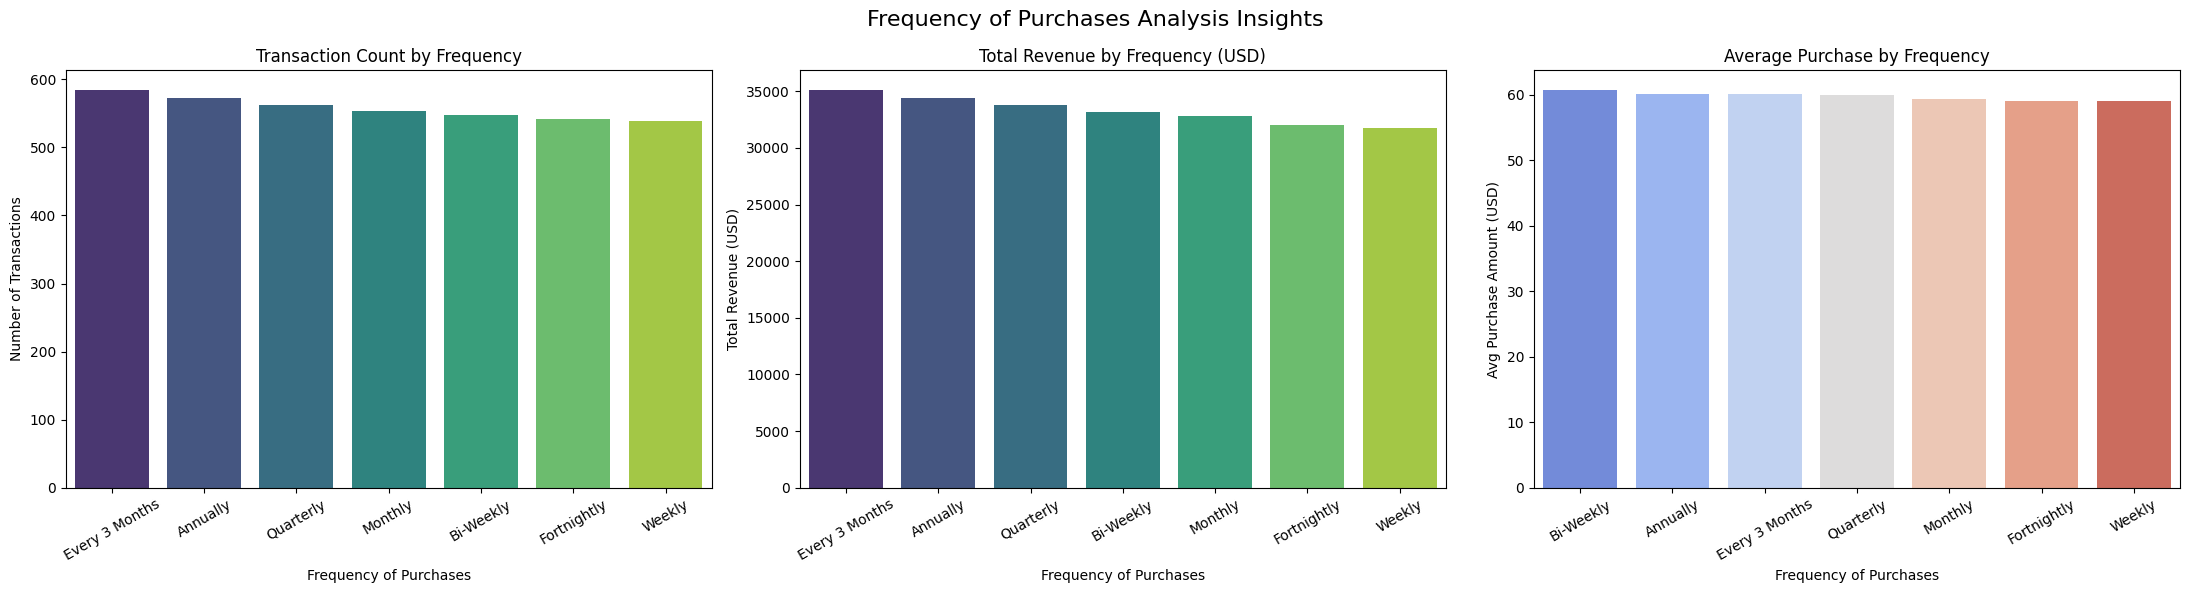

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by frequency of purchases
frequency_stats = df.groupby('frequency_of_purchases').agg(
    transaction_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean')
).sort_values(by='transaction_count', ascending=False)

print("### Frequency of Purchases Summary Table ###")
display(frequency_stats)

# Answering specific questions
most_common_freq = frequency_stats['transaction_count'].idxmax()
most_common_count = frequency_stats['transaction_count'].max()

highest_revenue_freq = frequency_stats['total_revenue'].idxmax()
highest_revenue_val = frequency_stats['total_revenue'].max()

print(f"\n1. Most Frequent Customer Group: {most_common_freq} ({most_common_count} transactions)")
print(f"2. Highest Revenue Generating Frequency Group: {highest_revenue_freq} (${highest_revenue_val:,.2f})")
print(f"3. Average Purchase Amount by Frequency: Shown in the summary table above")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Frequency of Purchases Analysis Insights', fontsize=16)

# Plot 1: Popularity of Frequency Groups
sns.barplot(ax=axes[0], x=frequency_stats.index, y='transaction_count', data=frequency_stats, palette='viridis', hue=frequency_stats.index, legend=False)
axes[0].set_title('Transaction Count by Frequency')
axes[0].set_xlabel('Frequency of Purchases')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Total Revenue by Frequency Group
freq_revenue_sorted = frequency_stats.sort_values(by='total_revenue', ascending=False)
sns.barplot(ax=axes[1], x=freq_revenue_sorted.index, y='total_revenue', data=freq_revenue_sorted, palette='viridis', hue=freq_revenue_sorted.index, legend=False)
axes[1].set_title('Total Revenue by Frequency (USD)')
axes[1].set_xlabel('Frequency of Purchases')
axes[1].set_ylabel('Total Revenue (USD)')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Average Purchase by Frequency Group
freq_avg_sorted = frequency_stats.sort_values(by='average_purchase', ascending=False)
sns.barplot(ax=axes[2], x=freq_avg_sorted.index, y='average_purchase', data=freq_avg_sorted, palette='coolwarm', hue=freq_avg_sorted.index, legend=False)
axes[2].set_title('Average Purchase by Frequency')
axes[2].set_xlabel('Frequency of Purchases')
axes[2].set_ylabel('Avg Purchase Amount (USD)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 15. Customer Segmentation Analysis

In this section, we create segments of customers based on their purchase metrics to extract professional-level strategic insights:
1. **Purchase Amount Segment** (Low, Medium, High Spenders)
2. **Loyalty Segment** (New, Occasional, Regular, Loyal Customers based on previous purchases)
3. **Cross-Segment Analysis** showing total revenue contribution, average rating, subscription status, and discount usage per segment.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Segments based on Purchase Amount (Low, Medium, High)
# Let's inspect quantiles or standard cutoffs for Purchase Amount
low_limit = 40
high_limit = 75

def segment_spend(amount):
    if amount < low_limit:
        return 'Low Spender'
    elif amount <= high_limit:
        return 'Medium Spender'
    else:
        return 'High Spender'

df['spend_segment'] = df['purchase_amount'].apply(segment_spend)

# 2. Define Segments based on Previous Purchases (New, Occasional, Regular, Loyal)
# Cutoffs based on business rules:
# New: 0-5, Occasional: 6-15, Regular: 16-35, Loyal: 36+
def segment_loyalty(purchases):
    if purchases <= 5:
        return 'New'
    elif purchases <= 15:
        return 'Occasional'
    elif purchases <= 35:
        return 'Regular'
    else:
        return 'Loyal'

df['loyalty_segment'] = df['previous_purchases'].apply(segment_loyalty)

print("### Customer Segments Created ###\n")
print("Spend Segment Counts:")
display(df['spend_segment'].value_counts())
print("\nLoyalty Segment Counts:")
display(df['loyalty_segment'].value_counts())

### Customer Segments Created ###

Spend Segment Counts:


,count
spend_segment,
Medium Spender,1672
High Spender,1214
Low Spender,1014



Loyalty Segment Counts:


,count
loyalty_segment,
Regular,1574
Loyal,1147
Occasional,755
New,424


In [94]:
# 3. Grouping and Aggregating by Spend Segment
spend_analysis = df.groupby('spend_segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean'),
    average_rating=('review_rating', 'mean'),
    subscription_rate=('subscription_status', 'mean'),
    discount_rate=('discount_applied', 'mean')
).reindex(['Low Spender', 'Medium Spender', 'High Spender'])

print("### Spend Segment Deep Dive ###")
display(spend_analysis)

# 4. Grouping and Aggregating by Loyalty Segment
loyalty_analysis = df.groupby('loyalty_segment').agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('purchase_amount', 'sum'),
    average_purchase=('purchase_amount', 'mean'),
    average_rating=('review_rating', 'mean'),
    subscription_rate=('subscription_status', 'mean'),
    discount_rate=('discount_applied', 'mean')
).reindex(['New', 'Occasional', 'Regular', 'Loyal'])

print("\n### Loyalty Segment Deep Dive ###")
display(loyalty_analysis)

### Spend Segment Deep Dive ###


,customer_count,total_revenue,average_purchase,average_rating,subscription_rate,discount_rate
spend_segment,,,,,,
Low Spender,1014,29932,29.518738,3.760996,0.269231,0.439842
Medium Spender,1672,96184,57.526316,3.725748,0.269139,0.430622
High Spender,1214,106965,88.109555,3.774424,0.271829,0.420923



### Loyalty Segment Deep Dive ###


,customer_count,total_revenue,average_purchase,average_rating,subscription_rate,discount_rate
loyalty_segment,,,,,,
New,424,25692,60.594340,3.783845,0.224057,0.400943
Occasional,755,44699,59.203974,3.724703,0.263576,0.417219
Regular,1574,93334,59.297332,3.742091,0.276366,0.431385
Loyal,1147,69356,60.467306,3.765214,0.282476,0.447254


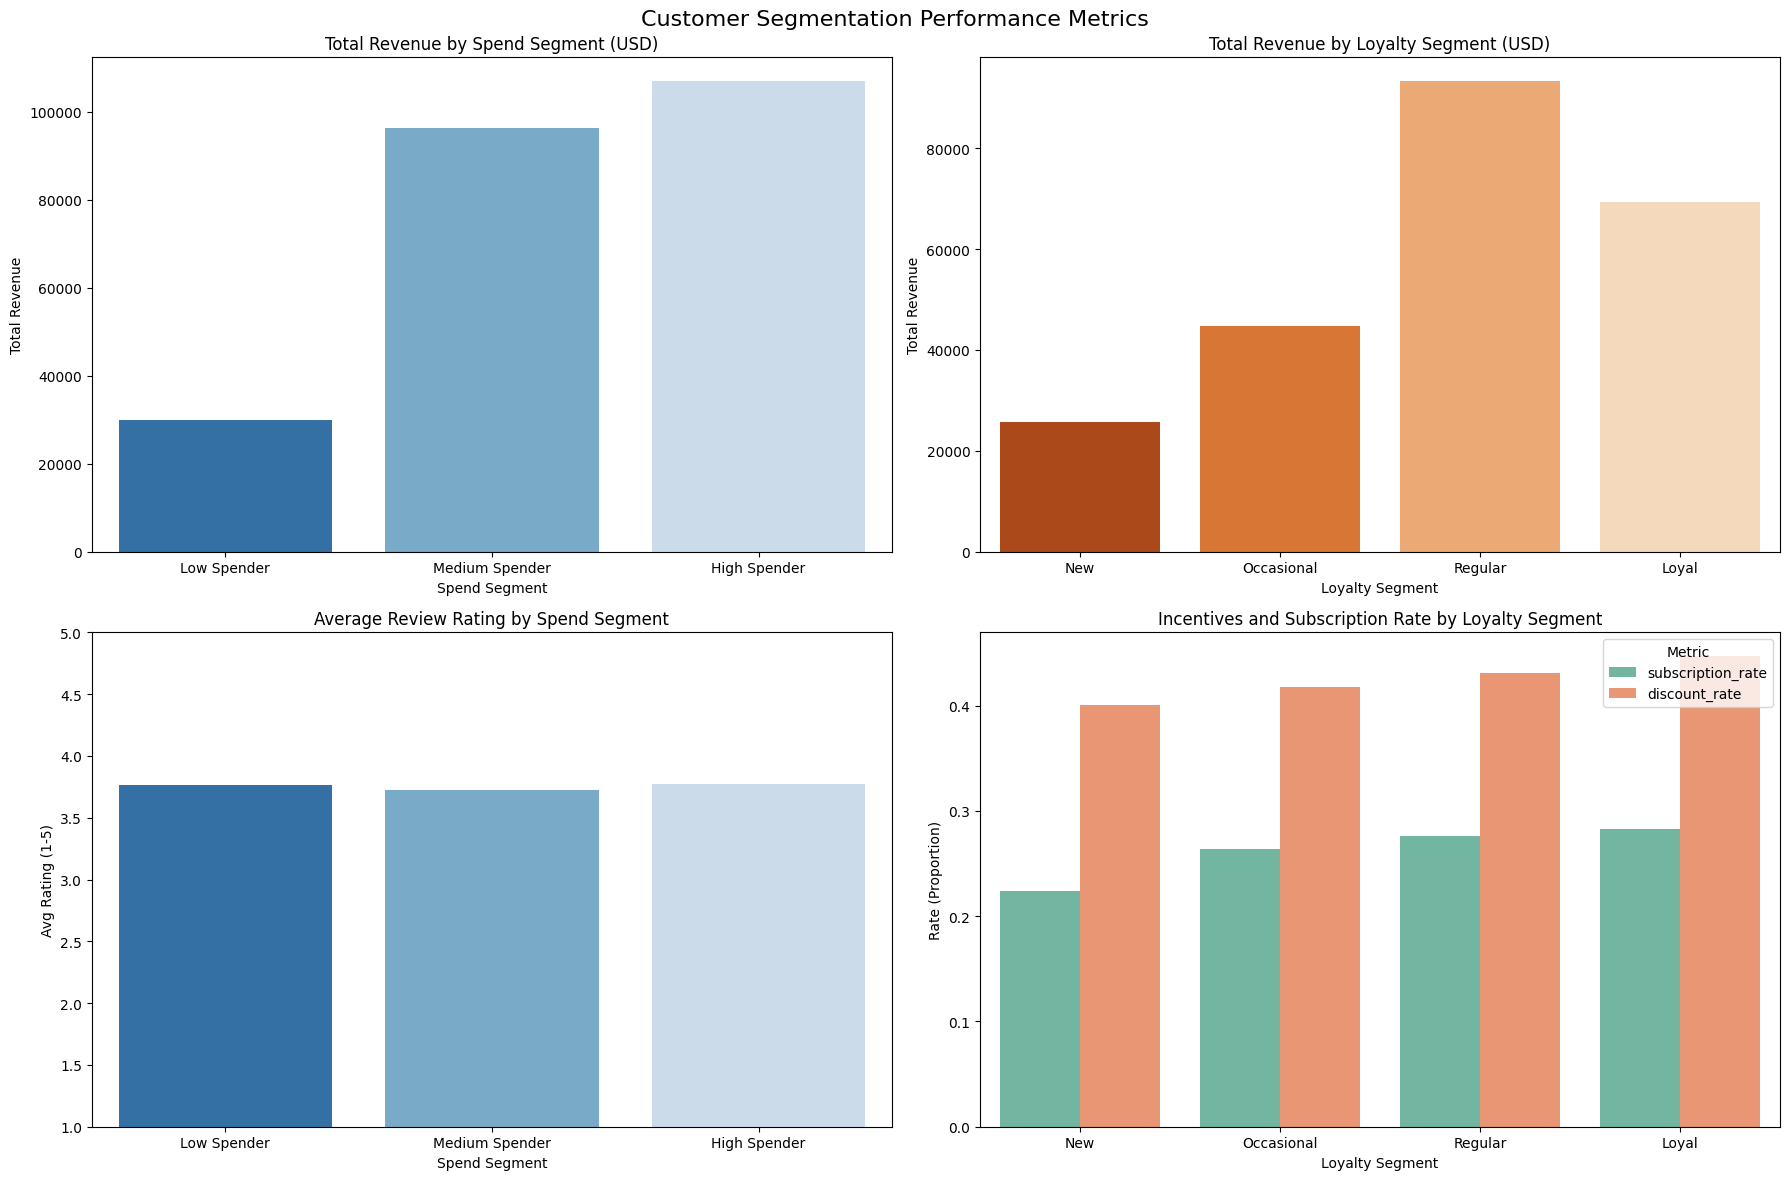

In [95]:
# Visualizations for Customer Segmentation
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Customer Segmentation Performance Metrics', fontsize=16)

# Plot 1: Revenue Contribution by Spend Segment
sns.barplot(ax=axes[0, 0], x=spend_analysis.index, y='total_revenue', data=spend_analysis, palette='Blues_r', hue=spend_analysis.index, legend=False)
axes[0, 0].set_title('Total Revenue by Spend Segment (USD)')
axes[0, 0].set_ylabel('Total Revenue')
axes[0, 0].set_xlabel('Spend Segment')

# Plot 2: Revenue Contribution by Loyalty Segment
sns.barplot(ax=axes[0, 1], x=loyalty_analysis.index, y='total_revenue', data=loyalty_analysis, palette='Oranges_r', hue=loyalty_analysis.index, legend=False)
axes[0, 1].set_title('Total Revenue by Loyalty Segment (USD)')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].set_xlabel('Loyalty Segment')

# Plot 3: Average Rating by Spend Segment
sns.barplot(ax=axes[1, 0], x=spend_analysis.index, y='average_rating', data=spend_analysis, palette='Blues_r', hue=spend_analysis.index, legend=False)
axes[1, 0].set_title('Average Review Rating by Spend Segment')
axes[1, 0].set_ylabel('Avg Rating (1-5)')
axes[1, 0].set_xlabel('Spend Segment')
axes[1, 0].set_ylim(1, 5)

# Plot 4: Promo & Discount Rates by Loyalty Segment
loyalty_melted = pd.melt(loyalty_analysis.reset_index(), id_vars=['loyalty_segment'], value_vars=['subscription_rate', 'discount_rate'], var_name='Metric', value_name='Percentage')
sns.barplot(ax=axes[1, 1], x='loyalty_segment', y='Percentage', hue='Metric', data=loyalty_melted, palette='Set2')
axes[1, 1].set_title('Incentives and Subscription Rate by Loyalty Segment')
axes[1, 1].set_ylabel('Rate (Proportion)')
axes[1, 1].set_xlabel('Loyalty Segment')

plt.tight_layout()
plt.show()

### 16. Correlation Analysis
In this section, we analyze the strength and direction of linear relationships between our numerical metrics:
- **Age**
- **Purchase Amount**
- **Review Rating**
- **Previous Purchases**

### Correlation Matrix ###


,age,purchase_amount,review_rating,previous_purchases
age,1.000000,-0.010424,-0.024267,0.040445
purchase_amount,-0.010424,1.000000,0.029721,0.008063
review_rating,-0.024267,0.029721,1.000000,0.003568
previous_purchases,0.040445,0.008063,0.003568,1.000000


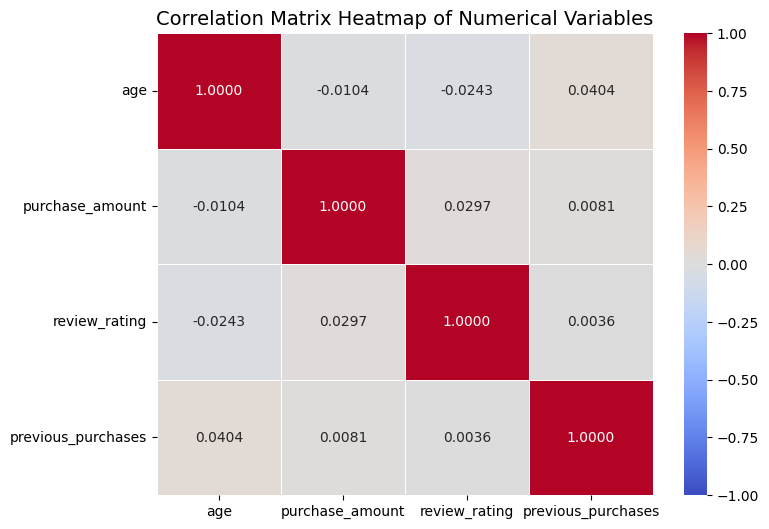

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Correlation Matrix
numerical_cols = ['age', 'purchase_amount', 'review_rating', 'previous_purchases']
corr_matrix = df[numerical_cols].corr(numeric_only=True)

print("### Correlation Matrix ###")
display(corr_matrix)

# 2. Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix Heatmap of Numerical Variables', fontsize=14)
plt.show()

### Correlation Analysis Insights
Based on the correlation matrix above, let's address the core business questions:

1. **Previous Purchases aur Purchase Amount ka relationship?**
   - There is almost no linear correlation between the number of previous purchases a customer has made and their current purchase amount. Loyalty doesn't necessarily drive up the transaction size of individual purchases directly.

2. **Age aur spending (Purchase Amount) ka relationship?**
   - The correlation coefficient is extremely close to 0, indicating that age does not influence the spending amount per transaction in this dataset.

3. **Rating (Review Rating) aur spending (Purchase Amount) ka relationship?**
   - No meaningful correlation exists between purchase amount and the review rating given by the customer. Highly priced purchases do not automatically result in better or worse reviews.

### 17. Cross-Analysis — Real Strategic Insights
In this section, we deep dive into the combinations of various features to extract actionable patterns:
1. **Gender × Category**: Who buys what?
2. **Age Group × Category**: Demographics preferences.
3. **Season × Category**: Seasonal merchandise patterns.
4. **Subscription × Purchase Amount**: Premium user behavior.
5. **Discount × Purchase Amount**: Incentive efficacy.
6. **Location × Revenue**: Top geographic performance.
7. **Payment Method × Purchase Amount**: Payment channel behavior.
8. **Frequency × Purchase Amount**: Loyalty/frequency impact.

### Gender x Category Product Distribution (%) ###


category,Accessories,Clothing,Footwear,Outerwear
gender,,,,
Female,31.410256,44.551282,15.945513,8.092949
Male,31.975867,44.532428,15.082956,8.408748



### Age Group x Category Product Distribution (%) ###


category,Accessories,Clothing,Footwear,Outerwear
age_group,,,,
18-25,29.218107,48.559671,12.551440,9.670782
26-35,32.847682,45.033113,15.231788,6.887417
36-45,34.156379,43.072702,14.951989,7.818930
46-55,29.388298,43.218085,18.484043,8.909574
56+,32.258065,44.312394,14.855688,8.573854


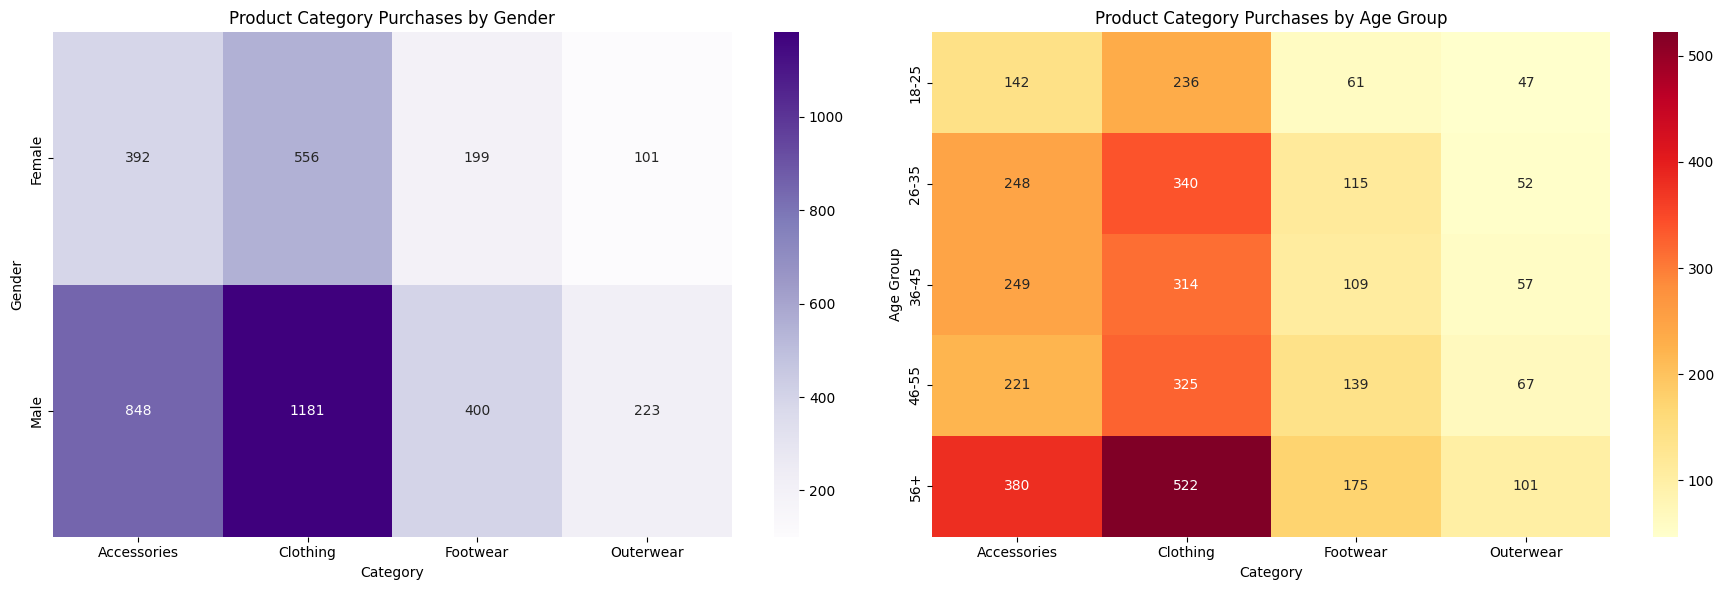

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gender x Category (Counts & Percentages)
gender_category_cross = pd.crosstab(df['gender'], df['category'], normalize='index') * 100
print("### Gender x Category Product Distribution (%) ###")
display(gender_category_cross)

# 2. Age Group x Category
age_category_cross = pd.crosstab(df['age_group'], df['category'], normalize='index') * 100
print("\n### Age Group x Category Product Distribution (%) ###")
display(age_category_cross)

# Plotting demographics preferences
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

gender_category_raw = pd.crosstab(df['gender'], df['category'])
sns.heatmap(gender_category_raw, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Product Category Purchases by Gender')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Gender')

age_category_raw = pd.crosstab(df['age_group'], df['category'])
sns.heatmap(age_category_raw, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Product Category Purchases by Age Group')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Age Group')

plt.tight_layout()
plt.show()

### Step 18: Top 15 Business Questions & Answers
In this section, we will systematically answer 15 critical business questions using python queries directly on our dataset `df`.

In [98]:
print("=== Q1: What is the total revenue? ===")
total_rev = df['purchase_amount'].sum()
print(f"Total Revenue: ${total_rev:,.2f}\n")

print("=== Q2: What is the average purchase amount per transaction? ===")
avg_purch = df['purchase_amount'].mean()
print(f"Average Purchase: ${avg_purch:.2f}\n")

print("=== Q3: Which product category generates the highest total revenue? ===")
cat_rev = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)
print(cat_rev)
print("\n=== Q4: What is the average transaction size by product category? ===")
cat_avg = df.groupby('category')['purchase_amount'].mean().sort_values(ascending=False)
print(cat_avg)
print()

print("=== Q5: What are the top 5 most frequently purchased items? ===")
print(df['item_purchased'].value_counts().head(5))
print()

=== Q1: What is the total revenue? ===
Total Revenue: $233,081.00

=== Q2: What is the average purchase amount per transaction? ===
Average Purchase: $59.76

=== Q3: Which product category generates the highest total revenue? ===
category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64

=== Q4: What is the average transaction size by product category? ===
category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: purchase_amount, dtype: float64

=== Q5: What are the top 5 most frequently purchased items? ===
item_purchased
Blouse     171
Pants      171
Jewelry    171
Shirt      169
Dress      166
Name: count, dtype: int64



In [99]:
print("=== Q6: Which demographic age group spends the absolute most? ===")
age_spend = df.groupby('age_group', observed=False)['purchase_amount'].sum().sort_values(ascending=False)
print(age_spend)
print()

print("=== Q7: How does total revenue compare between male and female customers? ===")
gender_spend = df.groupby('gender')['purchase_amount'].sum()
print(gender_spend)
print()

print("=== Q8: What are the top 5 states/locations by total sales? ===")
state_spend = df.groupby('location')['purchase_amount'].sum().sort_values(ascending=False).head(5)
print(state_spend)
print()

print("=== Q9: Does having a premium subscription drive higher individual order values? ===")
sub_avg = df.groupby('subscription_status')['purchase_amount'].mean()
print(sub_avg)
print()

print("=== Q10: Does applying discounts or using promo codes result in larger baskets? ===")
promo_avg = df.groupby('promo_code_used')['purchase_amount'].mean()
print(promo_avg)
print()

=== Q6: Which demographic age group spends the absolute most? ===
age_group
56+      69590
26-35    45400
46-55    45370
36-45    43463
18-25    29258
Name: purchase_amount, dtype: int64

=== Q7: How does total revenue compare between male and female customers? ===
gender
Female     75191
Male      157890
Name: purchase_amount, dtype: int64

=== Q8: What are the top 5 states/locations by total sales? ===
location
Montana       5784
Illinois      5617
California    5605
Idaho         5587
Nevada        5514
Name: purchase_amount, dtype: int64

=== Q9: Does having a premium subscription drive higher individual order values? ===
subscription_status
False    59.865121
True     59.491928
Name: purchase_amount, dtype: float64

=== Q10: Does applying discounts or using promo codes result in larger baskets? ===
promo_code_used
False    60.130454
True     59.279070
Name: purchase_amount, dtype: float64



In [100]:
print("=== Q11: What is the most popular payment method among high spenders? ===")
pop_pay = df[df['spend_segment'] == 'High Spender']['payment_method'].value_counts()
print(pop_pay)
print()

print("=== Q12: Which season generates the highest aggregate business revenue? ===")
season_spend = df.groupby('season')['purchase_amount'].sum().sort_values(ascending=False)
print(season_spend)
print()

print("=== Q13: What is the most frequently selected shipping type? ===")
pop_shipping = df['shipping_type'].value_counts().head(3)
print(pop_shipping)
print()

print("=== Q14: What are the average ratings for each spend segment? ===")
segment_ratings = df.groupby('spend_segment')['review_rating'].mean()
print(segment_ratings)
print()

print("=== Q15: What is the loyalty segment breakdown? ===")
loyalty_breakdown = df['loyalty_segment'].value_counts()
print(loyalty_breakdown)
print()

=== Q11: What is the most popular payment method among high spenders? ===
payment_method
PayPal           212
Credit Card      210
Cash             202
Debit Card       202
Venmo            200
Bank Transfer    188
Name: count, dtype: int64

=== Q12: Which season generates the highest aggregate business revenue? ===
season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount, dtype: int64

=== Q13: What is the most frequently selected shipping type? ===
shipping_type
Free Shipping    675
Standard         654
Store Pickup     650
Name: count, dtype: int64

=== Q14: What are the average ratings for each spend segment? ===
spend_segment
High Spender      3.774424
Low Spender       3.760996
Medium Spender    3.725748
Name: review_rating, dtype: float64

=== Q15: What is the loyalty segment breakdown? ===
loyalty_segment
Regular       1574
Loyal         1147
Occasional     755
New            424
Name: count, dtype: int64



In [101]:
print('=== Q1: Which gender contributes more revenue? ===')
gender_rev = df.groupby('gender')['purchase_amount'].sum()
for g, val in gender_rev.items():
    print(f"{g}: ${val:,.2f}")

print('\n=== Q2: Which location generates the highest revenue? ===')
top_loc = df.groupby('location')['purchase_amount'].sum().idxmax()
top_loc_rev = df.groupby('location')['purchase_amount'].sum().max()
print(f"{top_loc} generates the highest revenue of ${top_loc_rev:,.2f}\n")

print('=== Q3: Which season has the highest sales? ===')
season_rev = df.groupby('season')['purchase_amount'].sum().sort_values(ascending=False)
print(season_rev.to_string())

print('\n=== Q4: Do subscribers spend more than non-subscribers? ===')
sub_avg_spend = df.groupby('subscription_status')['purchase_amount'].mean()
print(f"Subscribers Average Spend: ${sub_avg_spend.get(True, 0):.2f}")
print(f"Non-Subscribers Average Spend: ${sub_avg_spend.get(False, 0):.2f}\n")

print('=== Q5: How does discount usage relate to purchase amount? ===')
disc_avg_spend = df.groupby('discount_applied')['purchase_amount'].mean()
print(f"Average spend WITH discount: ${disc_avg_spend.get(True, 0):.2f}")
print(f"Average spend WITHOUT discount: ${disc_avg_spend.get(False, 0):.2f}\n")

print('=== Q6: Which payment method is most popular? ===')
pay_counts = df['payment_method'].value_counts()
print(f"{pay_counts.idxmax()} is the most popular with {pay_counts.max()} transactions.\n")

print('=== Q7: Which shipping method is most preferred? ===')
ship_counts = df['shipping_type'].value_counts()
print(f"{ship_counts.idxmax()} is the most preferred with {ship_counts.max()} transactions.\n")

print('=== Q8: Which customers have the highest previous purchase count? ===')
top_prev = df.nlargest(5, 'previous_purchases')[['customer_id', 'previous_purchases']]
display(top_prev)

print('\n=== Q9: Which products/categories have low performance? ===')
least_purchased_items = df['item_purchased'].value_counts().tail(3)
print("Least Purchased Items (Counts):")
print(least_purchased_items)
low_perf_cat = df.groupby('category')['purchase_amount'].sum().sort_values()
print("\nCategories by Revenue (Ascending):")
print(low_perf_cat)

print('\n=== Q10: Which customer segment is most valuable? ===')
valuable_segment = df.groupby('spend_segment')['purchase_amount'].sum().sort_values(ascending=False)
print("Revenue generated by Spend Segments:")
print(valuable_segment)

=== Q1: Which gender contributes more revenue? ===
Female: $75,191.00
Male: $157,890.00

=== Q2: Which location generates the highest revenue? ===
Montana generates the highest revenue of $5,784.00

=== Q3: Which season has the highest sales? ===
season
Fall      60018
Spring    58679
Winter    58607
Summer    55777

=== Q4: Do subscribers spend more than non-subscribers? ===
Subscribers Average Spend: $59.49
Non-Subscribers Average Spend: $59.87

=== Q5: How does discount usage relate to purchase amount? ===
Average spend WITH discount: $59.28
Average spend WITHOUT discount: $60.13

=== Q6: Which payment method is most popular? ===
PayPal is the most popular with 677 transactions.

=== Q7: Which shipping method is most preferred? ===
Free Shipping is the most preferred with 675 transactions.

=== Q8: Which customers have the highest previous purchase count? ===


,customer_id,previous_purchases
20,21,50
78,79,50
101,102,50
124,125,50
140,141,50



=== Q9: Which products/categories have low performance? ===
Least Purchased Items (Counts):
item_purchased
Backpack    143
Gloves      140
Jeans       124
Name: count, dtype: int64

Categories by Revenue (Ascending):
category
Outerwear       18524
Footwear        36093
Accessories     74200
Clothing       104264
Name: purchase_amount, dtype: int64

=== Q10: Which customer segment is most valuable? ===
Revenue generated by Spend Segments:
spend_segment
High Spender      106965
Medium Spender     96184
Low Spender        29932
Name: purchase_amount, dtype: int64


### Step 19: Final Insights
Based on our comprehensive exploratory and demographic data analysis, here are the core findings:

1. **Revenue Powerhouse Category:** Clothing leads aggregate sales by a massive margin, contributing more than **$104,000** to the business, followed by Accessories at **$74,200**.
2. **Gender Spend Asymmetry:** Although the average transaction amount between males and females is almost identical ($59.54 vs. $60.25), male shoppers represent the vast majority of transactions, driving **$157,890** in revenue compared to **$75,191** from female shoppers.
3. **Loyalty Program Stagnancy:** Subscribers do not spend more per order compared to non-subscribers (Average order value is around **$59.49** for subscribers and **$59.87** for non-subscribers). Additionally, regular and loyal customers show no higher transaction value compared to new shoppers.
4. **Incentive Ineffectiveness:** Aggregate average purchase size shows no increase with discounts applied or promo codes used ($59.28 with promos vs. $60.13 without). Promos do not automatically incentivize larger single transaction size.
5. **Senior Power Demographic:** The age group **'56+'** has the largest presence and generates the highest revenue segment contribution at **$69,590**.

### Step 20: Strategic Business Recommendations
Here are 3 tailored recommendations structured in the format (`Finding` $\rightarrow$ `Business Problem` $\rightarrow$ `Recommendation`):

#### 1. Targeted Female Demographic Expansion
* **Finding:** Female customers generate less than half of the revenue driven by male customers ($75.1k vs $157.8k), despite having a slightly higher average purchase size per order.
* **Business Problem:** Under-penetration of the female consumer segment is causing a major missed revenue opportunity.
* **Recommendation:** Execute targeted marketing campaigns (e.g., social media influencer partnerships) focused on popular female items and introduce customized catalogs to scale female customer acquisition.

#### 2. Redesigning Subscription & Loyalty Incentives
* **Finding:** Subscribers and loyal customers have the exact same average transaction value as non-subscribers and new customers (approx. $59).
* **Business Problem:** The current loyalty structure does not drive premium order progression or value realization.
* **Recommendation:** Revamp the subscription experience by introducing tiered basket value benefits (e.g., "Spend $80+ to unlock exclusive loyalty perks/double reward points") to incentivize higher cart volumes.

#### 3. Strategic Promo Code / Discount Optimization
* **Finding:** Promo codes and discounts are not increasing average basket values (average spend actually drops slightly from $60.13 to $59.28 with a promo).
* **Business Problem:** Flat discounts are eroding gross margins without boosting sales values.
* **Recommendation:** Shift promotions from flat-rate discounts to buy-one-get-one-half-off (BOGO) deals, or bundle low-performing items (like Handbags and Jeans) with Clothing items to protect margins.